In [ ]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.3 MB/s eta 0:00:00


# Trabalho 2 - Ciência de Dados <hr>

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import anderson
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, coint
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import jensenshannon
import scipy.signal as signal
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from plotly.subplots import make_subplots
import ruptures as rpt
import warnings

warnings.filterwarnings('ignore')

# --- Funções de Processamento e Resolução de Gabor ---

def get_raw_data(ticker_map, start_date='2020-01-01'):
    """
    Downloads raw Close prices, renames them, and calculates log-returns and simple returns
    for daily (1), weekly (5), and monthly (21) windows.
    """
    tickers = list(ticker_map.keys())
    df = yf.download(tickers, start=start_date)['Close']
    df.rename(columns=ticker_map, inplace=True)

    raw_log_cols = []
    for col in ticker_map.values():
        # Daily (1)
        new_col_d = f'raw_log_ret_{col}'
        df[new_col_d] = np.log(df[col] / df[col].shift(1))
        raw_log_cols.append(new_col_d)

        # Weekly (5)
        df[f'raw_log_ret_w_{col}'] = np.log(df[col] / df[col].shift(5))

        # Monthly (21)
        df[f'raw_log_ret_m_{col}'] = np.log(df[col] / df[col].shift(21))

        # Simple returns
        df[f'raw_sim_ret_{col}'] = (df[col] / df[col].shift(1)) - 1
        df[f'raw_sim_ret_w_{col}'] = (df[col] / df[col].shift(5)) - 1
        df[f'raw_sim_ret_m_{col}'] = (df[col] / df[col].shift(21)) - 1

    return df, raw_log_cols

def gabor_resolution_analysis(df, assets, log_cols, energy_threshold=0.95):
    """
    Realiza a análise de resolução de Gabor para julgar a menor janela de suavização.
    Mede a densidade espectral de potência (PSD) dos log-retornos diários
    e encontra a frequência de corte que retém `energy_threshold` da potência total.
    Pelo princípio da incerteza de Gabor:
    Janela mínima W_min = ceil(1 / f_corte)
    """
    w_min_dict = {}
    psd_results = {}

    fig, axes = plt.subplots(len(assets), 2, figsize=(15, 3.5 * len(assets)))
    if len(assets) == 1:
        axes = [axes]

    for idx, (asset, col) in enumerate(zip(assets, log_cols)):
        data = df[col].dropna().values
        # Periodograma
        freqs, psd = signal.periodogram(data, fs=1.0)

        # Ignorar frequência zero (DC) para o cálculo da energia acumulada
        freqs = freqs[1:]
        psd = psd[1:]

        cum_psd = np.cumsum(psd)
        cum_psd_norm = cum_psd / cum_psd[-1]

        # Frequência de corte
        corte_idx = np.where(cum_psd_norm >= energy_threshold)[0][0]
        f_corte = freqs[corte_idx]
        w_min = int(np.ceil(1.0 / f_corte))
        w_min_dict[asset] = w_min

        # Salvar para plotting
        psd_results[asset] = {
            'freqs': freqs,
            'psd': psd,
            'cum_psd_norm': cum_psd_norm,
            'f_corte': f_corte,
            'w_min': w_min
        }

        # Plot da PSD
        ax_psd = axes[idx][0]
        ax_psd.plot(freqs, psd, color='blue', alpha=0.7)
        ax_psd.axvline(f_corte, color='red', linestyle='--', label=f'f_corte = {f_corte:.3f}')
        ax_psd.set_title(f'PSD: {asset}')
        ax_psd.set_xlabel('Frequência (ciclos/dia)')
        ax_psd.set_ylabel('Densidade')
        ax_psd.legend()

        # Plot da PSD Acumulada
        ax_cum = axes[idx][1]
        ax_cum.plot(freqs, cum_psd_norm, color='green', alpha=0.7)
        ax_cum.axvline(f_corte, color='red', linestyle='--')
        ax_cum.axhline(energy_threshold, color='magenta', linestyle=':', label=f'{energy_threshold*100:.0f}% energia')
        ax_cum.set_title(f'PSD Acumulada: {asset} (W_min = {w_min} dias)')
        ax_cum.set_xlabel('Frequência (ciclos/dia)')
        ax_cum.set_ylabel('Energia Acumulada')
        ax_cum.legend()

    plt.tight_layout()
    plt.show()

    # A janela global é o maior W_min entre todos os ativos (janela conservadora)
    global_w_min = max(w_min_dict.values())

    print("\n--- Resultados da Análise de Resolução de Gabor ---")
    for asset, w in w_min_dict.items():
        print(f"   {asset:>12s}: f_corte = {psd_results[asset]['f_corte']:.4f} Hz | Janela mínima W = {w} dias")
    print(f"👉 Janela recomendada unificada (máximo dos ativos): {global_w_min} dias\n")

    return global_w_min, w_min_dict

# --- Novas Funções de Médias Móveis Configuráveis ---

def compute_moving_average(series, window, method='sma'):
    """
    Função unificada que calcula a média móvel escolhida para uma dada série.
    Suporta: SMA, EMA, Triangular, Gaussian, DEMA, TEMA.
    """
    method = method.lower()
    if method == 'sma':
        return series.rolling(window=window).mean()
    elif method == 'ema':
        return series.ewm(span=window, adjust=False).mean()
    elif method == 'triangular':
        w1 = int(np.ceil((window + 1) / 2))
        w2 = window - w1 + 1
        return series.rolling(window=w1).mean().rolling(window=w2).mean()
    elif method == 'gaussian':
        # std=window/4 é o desvio padrão adequado para cobrir a janela
        return series.rolling(window=window, win_type='gaussian', min_periods=1, center=False).mean(std=window/4)
    elif method == 'dema':
        ema1 = series.ewm(span=window, adjust=False).mean()
        ema2 = ema1.ewm(span=window, adjust=False).mean()
        return 2 * ema1 - ema2
    elif method == 'tema':
        ema1 = series.ewm(span=window, adjust=False).mean()
        ema2 = ema1.ewm(span=window, adjust=False).mean()
        ema3 = ema2.ewm(span=window, adjust=False).mean()
        return 3 * ema1 - 3 * ema2 + ema3
    else:
        raise ValueError(f"Método de média móvel desconhecido: {method}")

def apply_smoothing_and_log_returns(df, assets, window, method='sma'):
    """
    Aplica média móvel de janela `window` (com método configurável) sobre cada coluna de preço Close,
    e calcula os log-retornos e retornos simples (diário, semanal e mensal) sobre a série suavizada.
    """
    df_smoothed = df.copy()
    log_ret_cols = []

    for asset in assets:
        smoothed_col = f'{asset}_smoothed'
        df_smoothed[smoothed_col] = compute_moving_average(df_smoothed[asset], window, method=method)

        # Log returns
        log_col = f'log_ret_{asset}'
        df_smoothed[log_col] = np.log(df_smoothed[smoothed_col] / df_smoothed[smoothed_col].shift(1))
        log_ret_cols.append(log_col)

        df_smoothed[f'log_ret_w_{asset}'] = np.log(df_smoothed[smoothed_col] / df_smoothed[smoothed_col].shift(5))
        df_smoothed[f'log_ret_m_{asset}'] = np.log(df_smoothed[smoothed_col] / df_smoothed[smoothed_col].shift(21))

        # Simple returns
        df_smoothed[f'sim_ret_{asset}'] = (df_smoothed[smoothed_col] / df_smoothed[smoothed_col].shift(1)) - 1
        df_smoothed[f'sim_ret_w_{asset}'] = (df_smoothed[smoothed_col] / df_smoothed[smoothed_col].shift(5)) - 1
        df_smoothed[f'sim_ret_m_{asset}'] = (df_smoothed[smoothed_col] / df_smoothed[smoothed_col].shift(21)) - 1

    return df_smoothed.dropna(), log_ret_cols

def plot_ma_phase_lag(df, asset, window, method='sma'):
    """
    Gera um gráfico interativo em Plotly comparando o preço original com o preço suavizado,
    destacando visualmente o phase lag (atraso de fase).
    """
    fig = go.Figure()

    # Preço original
    fig.add_trace(go.Scatter(
        x=df.index, y=df[asset],
        mode='lines',
        name='Preço Original',
        line=dict(color='gray', width=1.5, dash='dash')
    ))

    # Preço suavizado
    smoothed_series = compute_moving_average(df[asset], window, method=method)
    fig.add_trace(go.Scatter(
        x=df.index, y=smoothed_series,
        mode='lines',
        name=f'Suavizado ({method.upper()}, W={window})',
        line=dict(color='#00d2ff', width=2)
    ))

    fig.update_layout(
        title=f'Phase Lag (Atraso de Fase): {asset} | Preço Original vs. Suavizado {method.upper()} (W={window})',
        xaxis_title='Data',
        yaxis_title='Preço',
        hovermode='x unified',
        template='plotly_white',
        height=500
    )
    fig.show()

def compare_moving_averages(df, asset, window, methods=None):
    """
    Compara graficamente múltiplos métodos de médias móveis sobre a mesma série de preços.
    Permite visualizar interativamente qual método tem maior/menor suavização e atraso de fase.
    """
    if methods is None:
        methods = ['sma', 'ema', 'triangular', 'gaussian', 'dema', 'tema']

    fig = go.Figure()

    # Preço original
    fig.add_trace(go.Scatter(
        x=df.index, y=df[asset],
        mode='lines',
        name='Preço Original',
        line=dict(color='#888888', width=1.2, dash='dot')
    ))

    # Cores harmoniosas para os métodos
    colors = {
        'sma': '#1f77b4',
        'ema': '#ff7f0e',
        'triangular': '#2ca02c',
        'gaussian': '#d62728',
        'dema': '#9467bd',
        'tema': '#e377c2'
    }

    for m in methods:
        smoothed = compute_moving_average(df[asset], window, method=m)
        fig.add_trace(go.Scatter(
            x=df.index, y=smoothed,
            mode='lines',
            name=m.upper(),
            line=dict(color=colors.get(m, None), width=1.8)
        ))

    fig.update_layout(
        title=f'Comparação Estatística de Médias Móveis para {asset} (Janela W={window})',
        xaxis_title='Data',
        yaxis_title='Preço',
        hovermode='x unified',
        template='plotly_white',
        height=600
    )
    fig.show()

# --- Funções Estatísticas ---

def run_full_stats(df, assets, log_cols):
    # 1. Estatísticas Descritivas e AD
    stats = {}
    for asset, col in zip(assets, log_cols):
        data = df[col]
        ad_test = anderson(data, dist='norm')
        stats[asset] = {
            'Média': data.mean(),
            'DP': data.std(),
            'Skewness': data.skew(),
            'Kurtosis': data.kurt(),
            'Anderson-Stat': ad_test.statistic,
            'AD-Critico(5%)': ad_test.critical_values[2]
        }

    stats_df = pd.DataFrame(stats).T

    # 2. Plot da Matriz de Correlação
    plt.figure(figsize=(10, 8))
    corr_matrix = df[log_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
    plt.title('Matriz de Correlação de Pearson (Log-Retornos Suavizados)')
    plt.show()

    return stats_df

def run_autocorr_plots(df, assets, log_cols, lags=30):
    """
    Calcula e gera os plots da função de autocorrelação (ACF) para cada série.
    """
    num_assets = len(assets)
    fig, axes = plt.subplots(num_assets, 1, figsize=(10, 3 * num_assets))

    if num_assets == 1:
        axes = [axes]

    for i, (asset, col) in enumerate(zip(assets, log_cols)):
        plot_acf(df[col].dropna(), lags=lags, ax=axes[i], title=f'Autocorrelação (ACF): {asset}')
        axes[i].set_xlabel('Lags')
        axes[i].set_ylabel('Correlação')

    plt.tight_layout()
    plt.show()

def run_mutual_info_matrix(df, assets, log_cols, max_lags=30):
    results = []
    for asset_a, col_a in zip(assets, log_cols):
        for asset_b, col_b in zip(assets, log_cols):
            if asset_a == asset_b: continue
            best_mi = -1
            best_lag = -1
            for lag in range(1, max_lags + 1):
                temp = pd.DataFrame({'y': df[col_b], 'x': df[col_a].shift(lag)}).dropna()
                mi = mutual_info_regression(temp[['x']], temp['y'], random_state=42)[0]
                if mi > best_mi:
                    best_mi = mi
                    best_lag = lag
            results.append({'Ativo_A': asset_a, 'Ativo_B': asset_b, 'Lag': best_lag, 'MI': best_mi})
    return pd.DataFrame(results)

def run_granger_matrix(df, assets, log_cols, max_lags=30):
    results = []
    for cause_asset, cause_col in zip(assets, log_cols):
        for effect_asset, effect_col in zip(assets, log_cols):
            if cause_asset == effect_asset: continue
            data = df[[effect_col, cause_col]].dropna()
            res = grangercausalitytests(data, maxlag=max_lags, verbose=False)
            best_p = 1.1
            best_lag = -1
            for lag in range(1, max_lags + 1):
                p_val = res[lag][0]['ssr_ftest'][1]
                if p_val < best_p:
                    best_p = p_val
                    best_lag = lag
            results.append({'Causa': cause_asset, 'Efeito': effect_asset, 'Lag': best_lag, 'p_value': best_p})
    return pd.DataFrame(results)

def plot_interactive_heatmap(df_res, z_col, title, x_name='Efeito', y_name='Causa', colorscale='Viridis', reverse_z=False, zmax=None):
    if z_col == 'MI':
        df_pivot = df_res.pivot(index=y_name, columns=x_name, values=z_col)
        lag_pivot = df_res.pivot(index=y_name, columns=x_name, values='Lag')
        customdata = lag_pivot.values

        # Create text values for cell annotation showing MI and Lag
        text_values = []
        for r in range(df_pivot.shape[0]):
            row_text = []
            for c in range(df_pivot.shape[1]):
                val = df_pivot.values[r, c]
                lag_val = lag_pivot.values[r, c]
                if pd.isna(val):
                    row_text.append("")
                else:
                    row_text.append(f"{val:.3f}<br>(Lag {int(lag_val)})")
            text_values.append(row_text)

        fig = go.Figure(data=go.Heatmap(
            z=df_pivot.values,
            x=df_pivot.columns,
            y=df_pivot.index,
            customdata=customdata,
            colorscale=colorscale,
            reversescale=reverse_z,
            zmax=zmax,
            text=text_values,
            texttemplate="%{text}",
            hovertemplate=f'{y_name}: %{{y}}<br>{x_name}: %{{x}}<br>MI: %{{z:.4f}}<br>Lag Ótimo: %{{customdata}}<extra></extra>'
        ))
        fig.update_layout(title=title, xaxis_title=x_name, yaxis_title=y_name, height=600)
    elif z_col == 'p_value':
        df_pivot = df_res.pivot(index=y_name, columns=x_name, values=z_col)
        lag_pivot = df_res.pivot(index=y_name, columns=x_name, values='Lag')
        customdata = lag_pivot.values

        # Create text values for cell annotation showing p-value and Lag
        text_values = []
        for r in range(df_pivot.shape[0]):
            row_text = []
            for c in range(df_pivot.shape[1]):
                val = df_pivot.values[r, c]
                lag_val = lag_pivot.values[r, c]
                if pd.isna(val):
                    row_text.append("")
                else:
                    row_text.append(f"{val:.4f}<br>(Lag {int(lag_val)})")
            text_values.append(row_text)

        fig = go.Figure(data=go.Heatmap(
            z=df_pivot.values,
            x=df_pivot.columns,
            y=df_pivot.index,
            customdata=customdata,
            colorscale=colorscale,
            reversescale=reverse_z,
            zmax=zmax,
            text=text_values,
            texttemplate="%{text}",
            hovertemplate=f'{y_name}: %{{y}}<br>{x_name}: %{{x}}<br>p-value: %{{z:.4f}}<br>Lag Ótimo: %{{customdata}}<extra></extra>'
        ))
        fig.update_layout(title=title, xaxis_title=x_name, yaxis_title=y_name, height=600)
    else:
        df_pivot = df_res.pivot(index=y_name, columns=[x_name, 'Lag'], values=z_col)
        x_labels = [f"{c[0]} (Lag {c[1]})" for c in df_pivot.columns]
        fig = go.Figure(data=go.Heatmap(z=df_pivot.values, x=x_labels, y=df_pivot.index, colorscale=colorscale, reversescale=reverse_z, zmax=zmax, hovertemplate=f'{y_name}: %{{y}}<br>{x_name}: %{{x}}<br>Valor: %{{z:.4f}}<extra></extra>'))
        fig.update_layout(title=title, xaxis_title=f"{x_name} e Lag", yaxis_title=y_name, height=600)
    fig.show()

# --- Novo: Expoente de Hurst via Detrended Fluctuation Analysis (DFA) ---

def dfa(x, min_window=10, max_window=None):
    """
    Calcula o expoente de Hurst usando DFA (Detrended Fluctuation Analysis) linear (DFA1).
    """
    x = np.asarray(x)
    N = len(x)

    # 1. Perfil acumulado (acumulando desvios da média)
    y = np.cumsum(x - np.mean(x))

    if max_window is None:
        max_window = N // 4

    # Escalas espaçadas logaritmicamente
    scales = np.unique(np.logspace(np.log10(min_window), np.log10(max_window), num=20, dtype=int))

    fluctuations = []
    valid_scales = []

    for n in scales:
        if n < min_window or n > max_window:
            continue

        num_segments = N // n
        if num_segments == 0:
            continue

        segment_fluctuations = []
        for i in range(num_segments):
            start = i * n
            end = start + n
            segment_y = y[start:end]
            segment_x = np.arange(n)

            # Ajuste linear local (trend = a*x + b)
            coefs = np.polyfit(segment_x, segment_y, deg=1)
            trend = np.polyval(coefs, segment_x)

            # Resíduo quadrado médio (rms)
            rms = np.sqrt(np.mean((segment_y - trend) ** 2))
            segment_fluctuations.append(rms ** 2)

        if len(segment_fluctuations) > 0:
            F_n = np.sqrt(np.mean(segment_fluctuations))
            fluctuations.append(F_n)
            valid_scales.append(n)

    if len(valid_scales) < 3:
        return np.nan, [], []

    valid_scales = np.array(valid_scales)
    fluctuations = np.array(fluctuations)

    # Ajustar regressão linear log-log
    log_scales = np.log10(valid_scales)
    log_fluctuations = np.log10(fluctuations)

    slope, intercept = np.polyfit(log_scales, log_fluctuations, 1)
    return slope, valid_scales, fluctuations

def run_hurst_analysis(df, assets, log_cols, min_window=10, max_window=None):
    """
    Executa a análise do expoente de Hurst via DFA para os log-retornos dos ativos.
    Gera gráficos interativos em Plotly (ajuste log-log e barras comparativas).
    """
    hurst_results = []
    fig_loglog = go.Figure()

    for asset, col in zip(assets, log_cols):
        data = df[col].dropna().values
        H, scales, fluctuations = dfa(data, min_window=min_window, max_window=max_window)

        # Interpretação clássica
        if H < 0.45:
            interpret = "Anti-persistente (Reversão à Média)"
        elif H > 0.55:
            interpret = "Persistente (Trend-following)"
        else:
            interpret = "Random Walk (Eficiente)"

        hurst_results.append({
            'Ativo': asset,
            'Hurst (DFA)': H,
            'Interpretação': interpret
        })

        if len(scales) > 0:
            log_scales = np.log10(scales)
            log_fluct = np.log10(fluctuations)
            fit_y = H * log_scales + (log_fluct[0] - H * log_scales[0])

            fig_loglog.add_trace(go.Scatter(
                x=log_scales, y=log_fluct,
                mode='markers',
                name=f'{asset} (H={H:.3f})'
            ))
            fig_loglog.add_trace(go.Scatter(
                x=log_scales, y=fit_y,
                mode='lines',
                name=f'Ajuste {asset}',
                line=dict(dash='dash', width=1)
            ))

    fig_loglog.update_layout(
        title='Detrended Fluctuation Analysis (DFA) — Ajuste Linear Log-Log',
        xaxis_title='log10(Escala n)',
        yaxis_title='log10(Flutuação F(n))',
        template='plotly_white',
        height=500
    )
    fig_loglog.show()

    hurst_df = pd.DataFrame(hurst_results)

    # Gráfico de barras comparativo
    fig_bar = px.bar(
        hurst_df,
        x='Ativo', y='Hurst (DFA)',
        color='Hurst (DFA)',
        color_continuous_scale='Portland',
        range_color=[0.25, 0.75],
        title='Expoente de Hurst (DFA) por Ativo',
        text_auto='.3f'
    )
    fig_bar.add_hline(y=0.5, line_dash="dash", line_color="white", annotation_text="Passeio Aleatório (H=0.5)")
    fig_bar.update_layout(template='plotly_white', height=450)
    fig_bar.show()

    return hurst_df

# --- Novo: Cointegração Engle-Granger e Johansen ---

def run_engle_granger_cointegration(df, assets):
    """
    Executa o teste de cointegração de Engle-Granger (par a par) usando as séries fornecidas.
    Realiza teste de Dickey-Fuller Aumentado (ADF) prévio e pula a cointegração se alguma série for estacionária.
    Retorna o DataFrame de resultados e os spreads residuais.
    """
    results = []
    n = len(assets)
    coint_matrix = pd.DataFrame(np.ones((n, n)), index=assets, columns=assets)
    residuals_dict = {}

    for i, asset_a in enumerate(assets):
        for j, asset_b in enumerate(assets):
            if asset_a == asset_b:
                coint_matrix.iloc[i, j] = np.nan
                continue

            temp = df[[asset_a, asset_b]].dropna()
            y0 = temp[asset_a]
            y1 = temp[asset_b]

            # Teste ADF para verificar estacionariedade
            adf_a = adfuller(y0)
            adf_b = adfuller(y1)
            p_adf_a = adf_a[1]
            p_adf_b = adf_b[1]

            is_stat_a = p_adf_a < 0.05
            is_stat_b = p_adf_b < 0.05

            if is_stat_a or is_stat_b:
                # Pula o teste de cointegração
                score = np.nan
                p_value = np.nan
                crit_value_5 = np.nan
                beta = np.nan
                alpha = np.nan
                cointegrado = False
                status = f"Pulado (Estacionário: {asset_a if is_stat_a else ''} {'e ' if (is_stat_a and is_stat_b) else ''} {asset_b if is_stat_b else ''})"
                residuals_dict[f"{asset_a}_vs_{asset_b}"] = pd.Series(np.nan, index=temp.index)
            else:
                # Ambas são não-estacionárias: Executar cointegração
                score, p_value, crit_value = coint(y0, y1)
                crit_value_5 = crit_value[1]

                # Estimar Beta via OLS
                X = add_constant(y1)
                model = OLS(y0, X).fit()
                beta = model.params[asset_b]
                alpha = model.params['const']

                # Spread residual
                resid = y0 - (alpha + beta * y1)
                residuals_dict[f"{asset_a}_vs_{asset_b}"] = resid

                cointegrado = p_value < 0.05
                status = "Executado"

            results.append({
                'Ativo_A': asset_a,
                'Ativo_B': asset_b,
                'Beta': beta,
                'Alpha': alpha,
                'coint_stat': score,
                'p_value': p_value,
                'coint_crit_5%': crit_value_5,
                'Cointegrado': cointegrado,
                'Status': status
            })
            coint_matrix.iloc[i, j] = p_value

    coint_df = pd.DataFrame(results)

    # Heatmap de P-Values
    fig = go.Figure(data=go.Heatmap(
        z=coint_matrix.values,
        x=coint_matrix.columns.tolist(),
        y=coint_matrix.index.tolist(),
        colorscale='Viridis',
        zmin=0.0, zmax=1.0,
        text=np.round(coint_matrix.values, 4),
        texttemplate="%{text}",
        hovertemplate='Y: %{y}<br>X: %{x}<br>p-value: %{z:.4f}<extra></extra>'
    ))
    fig.update_layout(
        title='Teste de Cointegração Engle-Granger (Heatmap de P-Values)<br><sup>p-values < 0.05 indicam cointegração significativa</sup>',
        xaxis_title='Ativo B (Independente)',
        yaxis_title='Ativo A (Dependente)',
        template='plotly_white',
        height=500
    )
    fig.show()

    return coint_df, residuals_dict

def run_johansen_cointegration(df, assets, det_order=0, k_ar_diff=1):
    """
    Executa o teste de cointegração multivariado de Johansen nas séries fornecidas.
    Verifica se há alguma série estacionária via ADF e avisa/pula caso detectado.
    Exibe tabelas estilizadas dos resultados de significância a 95%.
    """
    temp = df[assets].dropna()

    # Teste ADF prévio para cada série
    stationary_assets = []
    for asset in assets:
        p_val_adf = adfuller(temp[asset])[1]
        if p_val_adf < 0.05:
            stationary_assets.append(asset)

    if len(stationary_assets) > 0:
        print(f"⚠️ Teste de Johansen pulado pois as seguintes séries são estacionárias (p-value ADF < 0.05): {stationary_assets}")
        return pd.DataFrame()

    res = coint_johansen(temp, det_order=det_order, k_ar_diff=k_ar_diff)

    trace_stats = res.lr1
    trace_crit = res.cvt[:, 1]  # 95%
    max_eig_stats = res.lr2
    max_eig_crit = res.cvm[:, 1]  # 95%

    johansen_results = []
    n = len(assets)
    for i in range(n):
        trace_sig = trace_stats[i] > trace_crit[i]
        max_eig_sig = max_eig_stats[i] > max_eig_crit[i]

        johansen_results.append({
            'Hipótese Nula (H0)': f'r <= {i}',
            'Estatística Traço': trace_stats[i],
            'V. Crítico Traço (95%)': trace_crit[i],
            'Traço Rejeita H0': 'Sim' if trace_sig else 'Não',
            'Estatística Max-Eig': max_eig_stats[i],
            'V. Crítico Max-Eig (95%)': max_eig_crit[i],
            'Max-Eig Rejeita H0': 'Sim' if max_eig_sig else 'Não'
        })

    johansen_df = pd.DataFrame(johansen_results)

    fig = go.Figure(data=[go.Table(
        header=dict(
            values=list(johansen_df.columns),
            fill_color='indigo',
            align='center',
            font=dict(color='white', size=12)
        ),
        cells=dict(
            values=[johansen_df[col] for col in johansen_df.columns],
            fill_color='rgba(45, 45, 45, 0.9)',
            align='center',
            font=dict(color='white', size=11),
            format=[None, '.4f', '.4f', None, '.4f', '.4f', None]
        )
    )])
    fig.update_layout(
        title='Teste de Cointegração Multivariado de Johansen (Significância de 95%)',
        template='plotly_white',
        height=320
    )
    fig.show()

    return johansen_df

# --- Novo: Decomposição Sazonal ---

def run_seasonal_decomposition(df, assets, cols, period=21, model='additive'):
    """
    Aplica a decomposição sazonal clássica aditiva: S_e(t) = T(t) + S_a(t) + Resid(t)
    Retorna os resíduos de decomposição para teste ADF e gera gráficos integrados com Plotly.
    """
    decomp_residuals = {}

    for asset, col in zip(assets, cols):
        series = df[col].dropna()
        res = seasonal_decompose(series, model=model, period=period, extrapolate_trend='freq')

        decomp_residuals[f"{asset}_resid"] = res.resid

        fig = make_subplots(
            rows=4, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.06,
            subplot_titles=(
                f'Série Original: {col}',
                'Componente de Tendência: T(t)',
                f'Componente Sazonal: S(t) [Período = {period} dias]',
                'Componente Residual (Ruído): Resid(t)'
            )
        )

        fig.add_trace(go.Scatter(x=series.index, y=series, name='Original', line=dict(color='cyan', width=1.5)), row=1, col=1)
        fig.add_trace(go.Scatter(x=series.index, y=res.trend, name='Tendência', line=dict(color='yellow', width=1.5)), row=2, col=1)
        fig.add_trace(go.Scatter(x=series.index, y=res.seasonal, name='Sazonalidade', line=dict(color='magenta', width=1.5)), row=3, col=1)
        fig.add_trace(go.Scatter(x=series.index, y=res.resid, name='Resíduo', line=dict(color='orange', width=1.5)), row=4, col=1)

        fig.update_layout(
            title=f'Decomposição Sazonal Aditiva para {asset} (Período = {period})',
            xaxis4_title='Data',
            template='plotly_white',
            height=750,
            showlegend=False
        )
        fig.show()

    return decomp_residuals

# --- Novo: Teste Augmented Dickey-Fuller (ADF) ---

def run_adf_tests(series_dict, regression='c'):
    """
    Função genérica que aplica o teste ADF para um dicionário de séries temporais.
    Exibe os resultados consolidados em uma tabela interativa colorida.
    """
    results = []

    for name, series in series_dict.items():
        clean_series = series.dropna()
        if len(clean_series) < 10:
            continue

        adf_stat, p_value, lags_used, nobs, crit_values, _ = adfuller(clean_series, regression=regression)
        estacionaria = p_value < 0.05

        results.append({
            'Série': name,
            'Estatística ADF': adf_stat,
            'p-value': p_value,
            'Lags Usados': lags_used,
            'Observações': nobs,
            'Crit 1%': crit_values['1%'],
            'Crit 5%': crit_values['5%'],
            'Crit 10%': crit_values['10%'],
            'Estacionária': 'Sim' if estacionaria else 'Não'
        })

    df_adf = pd.DataFrame(results)

    # Cores de destaque na coluna Estacionária
    fill_colors = []
    for est in df_adf['Estacionária']:
        if est == 'Sim':
            fill_colors.append('rgba(46, 204, 113, 0.35)')  # Verde suave
        else:
            fill_colors.append('rgba(231, 76, 60, 0.35)')   # Vermelho suave

    cell_colors = []
    for col in df_adf.columns:
        if col == 'Estacionária':
            cell_colors.append(fill_colors)
        else:
            cell_colors.append(['rgba(45, 45, 45, 0.9)'] * len(df_adf))

    fig = go.Figure(data=[go.Table(
        header=dict(
            values=list(df_adf.columns),
            fill_color='rgba(29, 39, 49, 1)',
            align='center',
            font=dict(color='white', size=12)
        ),
        cells=dict(
            values=[df_adf[col] for col in df_adf.columns],
            fill_color=cell_colors,
            align='center',
            font=dict(color='white', size=11),
            format=[None, '.4f', '.4f', None, None, '.4f', '.4f', '.4f', None]
        )
    )])

    fig.update_layout(
        title='Resultados do Teste Augmented Dickey-Fuller (ADF) (Significância de 5%)',
        template='plotly_white',
        height=min(130 + 40 * len(df_adf), 500)
    )
    fig.show()

    return df_adf

# --- Novo: Teste de Quebra Estrutural (Bai-Perron / PELT) ---

def run_structural_breaks(df, assets, model='l2', min_size=21, penalty_factor=3.0):
    """
    Detecta múltiplos pontos de quebra estrutural nas séries de preços Close
    utilizando o algoritmo PELT da biblioteca ruptures.
    Gera gráficos de série temporal com segmentos destacados.
    """
    results = []

    for asset in assets:
        series = df[asset].dropna()
        data = series.values

        # Penalidade baseada no tamanho e variância da série (padrão BIC)
        variance = np.var(data)
        pen = penalty_factor * np.log(len(data)) * variance

        # Algoritmo Pelt (Pruned Exact Linear Time)
        algo = rpt.Pelt(model=model, min_size=min_size).fit(data)
        try:
            break_points = algo.predict(pen=pen)
        except Exception:
            break_points = algo.predict(pen=1.0)

        # O último índice é o tamanho do sinal, descartamos como ponto de quebra real
        break_indices = break_points[:-1]
        break_dates = [series.index[idx].strftime('%Y-%m-%d') for idx in break_indices]

        results.append({
            'Ativo': asset,
            'N_Quebras': len(break_indices),
            'Datas_Quebras': ", ".join(break_dates) if break_dates else "Nenhuma quebra"
        })

        # Visualização
        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=series.index, y=series,
            mode='lines',
            name=f'Preço {asset}',
            line=dict(color='#00e676', width=2)
        ))

        for date_str in break_dates:
            fig.add_vline(x=date_str, line_dash="dash", line_color="#ff9100")

        segment_ends = break_points
        segment_starts = [0] + segment_ends[:-1]

        # Colorir segmentos adjacentes alternadamente
        colors = ['rgba(255, 235, 59, 0.04)', 'rgba(0, 229, 255, 0.04)']
        for idx, (start, end) in enumerate(zip(segment_starts, segment_ends)):
            if end >= len(series):
                end = len(series) - 1
            fig.add_vrect(
                x0=series.index[start], x1=series.index[end],
                fillcolor=colors[idx % 2],
                layer="below", line_width=0
            )

        fig.update_layout(
            title=f'Quebras Estruturais de Regime de Preço em {asset} (PELT, Janela Mínima = {min_size})',
            xaxis_title='Data',
            yaxis_title='Preço Close',
            template='plotly_white',
            height=450
        )
        fig.show()

    breaks_df = pd.DataFrame(results)
    return breaks_df

# --- Funções de Entropia e Divergência ---

def _discretize_series(series, n_bins=50):
    """Discretiza uma série contínua em uma distribuição de probabilidades via histograma."""
    counts, _ = np.histogram(series.dropna(), bins=n_bins)
    probs = counts / counts.sum()
    return probs

def _discretize_pair_common_bins(s1, s2, n_bins=50):
    """Discretiza duas séries com bins comuns (mesmo range) para comparação justa."""
    combined = pd.concat([s1, s2]).dropna()
    bin_edges = np.linspace(combined.min(), combined.max(), n_bins + 1)
    p1, _ = np.histogram(s1.dropna(), bins=bin_edges)
    p2, _ = np.histogram(s2.dropna(), bins=bin_edges)
    # Adiciona pseudocontagem para evitar log(0)
    p1 = (p1 + 1e-10) / (p1 + 1e-10).sum()
    p2 = (p2 + 1e-10) / (p2 + 1e-10).sum()
    return p1, p2

def run_entropy_analysis(df, assets, log_cols, n_bins=50):
    """
    Calcula a Entropia de Shannon H(X) para cada série de log-retornos.
    """
    results = []
    for asset, col in zip(assets, log_cols):
        probs = _discretize_series(df[col], n_bins=n_bins)
        probs = probs[probs > 0]
        h = scipy_entropy(probs, base=2)  # bits
        results.append({'Ativo': asset, 'Entropia (bits)': h})

    entropy_df = pd.DataFrame(results).set_index('Ativo')

    # Visualização: barras interativas
    fig = px.bar(
        entropy_df.reset_index(),
        x='Ativo', y='Entropia (bits)',
        title='Entropia de Shannon por Ativo (Log-Retornos Suavizados)',
        color='Entropia (bits)',
        color_continuous_scale='Viridis',
        text_auto='.3f'
    )
    fig.update_layout(height=450, template='plotly_white')
    fig.show()

    return entropy_df

def run_jsd_matrix(df, assets, log_cols, n_bins=50):
    """
    Calcula a Divergência de Jensen-Shannon entre todas as combinações de pares.
    """
    n = len(assets)
    jsd_matrix = pd.DataFrame(np.zeros((n, n)), index=assets, columns=assets)

    for i in range(n):
        for j in range(i + 1, n):
            p1, p2 = _discretize_pair_common_bins(df[log_cols[i]], df[log_cols[j]], n_bins=n_bins)
            jsd_val = jensenshannon(p1, p2, base=2)
            jsd_matrix.iloc[i, j] = jsd_val ** 2
            jsd_matrix.iloc[j, i] = jsd_val ** 2

    # Visualização: heatmap
    fig = go.Figure(data=go.Heatmap(
        z=jsd_matrix.values,
        x=jsd_matrix.columns.tolist(),
        y=jsd_matrix.index.tolist(),
        colorscale='RdYlGn_r',
        zmin=0, zmax=jsd_matrix.values.max(),
        hovertemplate='%{y} vs %{x}<br>JSD: %{z:.4f}<extra></extra>'
    ))
    fig.update_layout(
        title='Divergência de Jensen-Shannon (JSD) entre Distribuições de Log-Retornos',
        template='plotly_white',
        height=500
    )
    fig.show()

    return jsd_matrix

# --- Funções de Transferência de Entropia ---

def _estimate_te(source, target_now, target_past, n_bins=10):
    """
    Estima Transfer Entropy: TE(source -> target) usando histogramas multidimensionais.
    TE = H(target_now | target_past) - H(target_now | target_past, source_past)
    """
    # H(target_now, target_past) - H(target_past)
    data_2d = np.column_stack([target_now, target_past])
    hist_2d, _ = np.histogramdd(data_2d, bins=n_bins)
    hist_1d_past, _ = np.histogram(target_past, bins=n_bins)

    p_2d = hist_2d / hist_2d.sum()
    p_1d = hist_1d_past / hist_1d_past.sum()

    h_joint_2d = scipy_entropy(p_2d.flatten() + 1e-15, base=2)
    h_past = scipy_entropy(p_1d + 1e-15, base=2)
    h_cond_no_source = h_joint_2d - h_past

    # H(target_now, target_past, source_past) - H(target_past, source_past)
    data_3d = np.column_stack([target_now, target_past, source])
    hist_3d, _ = np.histogramdd(data_3d, bins=n_bins)
    data_2d_ps = np.column_stack([target_past, source])
    hist_2d_ps, _ = np.histogramdd(data_2d_ps, bins=n_bins)

    p_3d = hist_3d / hist_3d.sum()
    p_2d_ps = hist_2d_ps / hist_2d_ps.sum()

    h_joint_3d = scipy_entropy(p_3d.flatten() + 1e-15, base=2)
    h_past_source = scipy_entropy(p_2d_ps.flatten() + 1e-15, base=2)
    h_cond_with_source = h_joint_3d - h_past_source

    te = max(h_cond_no_source - h_cond_with_source, 0.0)
    return te

def get_optimal_mi_lags(mi_df, assets):
    """
    Extrai, para cada par (source, target), o lag que maximiza a informação mútua (MI).
    Retorna um dicionário {(source, target): lag}.
    """
    lag_map = {}
    for a in assets:
        for b in assets:
            if a == b:
                continue
            pair_df = mi_df[(mi_df['Ativo_A'] == a) & (mi_df['Ativo_B'] == b)]
            if len(pair_df) > 0:
                idx_max = pair_df['MI'].idxmax()
                best_lag = int(pair_df.loc[idx_max, 'Lag'])
                lag_map[(a, b)] = best_lag
            else:
                lag_map[(a, b)] = 1
    return lag_map

def run_transfer_entropy_matrix(df, assets, log_cols, lag_map, n_bins=10):
    """
    Calcula TE bivariate entre todos os pares de ativos usando os lags que maximizam a MI.
    """
    results = []
    max_lag = max(list(lag_map.values()) + [1])

    for i, (target_asset, target_col) in enumerate(zip(assets, log_cols)):
        for j, (source_asset, source_col) in enumerate(zip(assets, log_cols)):
            if i == j:
                continue

            lag = lag_map.get((source_asset, target_asset), 1)
            target_series = df[target_col].values
            source_series = df[source_col].values

            # Alinhamento correto de tempo:
            target_now = target_series[max_lag:]
            target_past = target_series[max_lag - 1 : -1]
            source_past = source_series[max_lag - lag : -lag]

            mask = ~(np.isnan(target_now) | np.isnan(target_past) | np.isnan(source_past))
            te = _estimate_te(source_past[mask], target_now[mask], target_past[mask], n_bins=n_bins)

            results.append({
                'Fonte': source_asset,
                'Alvo': target_asset,
                'Lag': lag,
                'TE': te
            })

    te_df = pd.DataFrame(results)

    # Visualização: heatmap
    te_pivot = te_df.pivot(index='Fonte', columns='Alvo', values='TE')
    fig = go.Figure(data=go.Heatmap(
        z=te_pivot.values,
        x=te_pivot.columns.tolist(),
        y=te_pivot.index.tolist(),
        colorscale='Hot_r',
        hovertemplate='Fonte: %{y}<br>Alvo: %{x}<br>TE: %{z:.4f}<extra></extra>'
    ))
    fig.update_layout(
        title='Transferência de Entropia Bivariate com Lags Ótimos da MI',
        xaxis_title='Alvo',
        yaxis_title='Fonte',
        template='plotly_white',
        height=500
    )
    fig.show()

    return te_df

def run_conditional_transfer_entropy(df, assets, log_cols, target, lag_map, n_bins=10):
    """
    Para um ativo alvo, calcula TE(B -> A | C) usando os lags que maximizam a MI.
    """
    target_idx = assets.index(target)
    target_col = log_cols[target_idx]
    target_series = df[target_col].values

    results = []
    other_assets = [(a, c) for a, c in zip(assets, log_cols) if a != target]
    max_lag = max(list(lag_map.values()) + [1])

    for source_asset, source_col in other_assets:
        source_series = df[source_col].values
        lag_s = lag_map.get((source_asset, target), 1)

        for cond_asset, cond_col in other_assets:
            if cond_asset == source_asset:
                continue
            cond_series = df[cond_col].values
            lag_c = lag_map.get((cond_asset, target), 1)

            # Alinhamento
            target_now = target_series[max_lag:]
            target_past = target_series[max_lag - 1 : -1]
            source_past = source_series[max_lag - lag_s : -lag_s]
            cond_past = cond_series[max_lag - lag_c : -lag_c]

            mask = ~(np.isnan(target_now) | np.isnan(target_past) |
                     np.isnan(source_past) | np.isnan(cond_past))

            tn = target_now[mask]
            tp = target_past[mask]
            sp = source_past[mask]
            cp = cond_past[mask]

            if len(tn) < 10:
                continue

            # H(A_t | A_{t-1}, C_{t-lag_c})
            data_3d_ac = np.column_stack([tn, tp, cp])
            hist_3d_ac, _ = np.histogramdd(data_3d_ac, bins=n_bins)
            data_2d_ac = np.column_stack([tp, cp])
            hist_2d_ac, _ = np.histogramdd(data_2d_ac, bins=n_bins)

            h_joint_ac = scipy_entropy(hist_3d_ac.flatten() / hist_3d_ac.sum() + 1e-15, base=2)
            h_past_ac = scipy_entropy(hist_2d_ac.flatten() / hist_2d_ac.sum() + 1e-15, base=2)
            h_cond_with_c = h_joint_ac - h_past_ac

            # H(A_t | A_{t-1}, B_{t-lag_s}, C_{t-lag_c})
            data_4d = np.column_stack([tn, tp, sp, cp])
            hist_4d, _ = np.histogramdd(data_4d, bins=n_bins)
            data_3d_psc = np.column_stack([tp, sp, cp])
            hist_3d_psc, _ = np.histogramdd(data_3d_psc, bins=n_bins)

            h_joint_4d = scipy_entropy(hist_4d.flatten() / hist_4d.sum() + 1e-15, base=2)
            h_past_sc = scipy_entropy(hist_3d_psc.flatten() / hist_3d_psc.sum() + 1e-15, base=2)
            h_cond_with_bc = h_joint_4d - h_past_sc

            cte = max(h_cond_with_c - h_cond_with_bc, 0.0)
            results.append({
                'Fonte': source_asset,
                'Condicionante': cond_asset,
                'Alvo': target,
                'CTE': cte
            })

    cte_df = pd.DataFrame(results)

    if len(results) == 0:
        print("  (Sem dados suficientes para calcular a Transferência de Entropia Condicional)")
        return pd.DataFrame(columns=['Fonte', 'Condicionante', 'Alvo', 'CTE'])

    # Visualização: heatmap
    cte_pivot = cte_df.pivot(index='Fonte', columns='Condicionante', values='CTE')
    fig = go.Figure(data=go.Heatmap(
        z=cte_pivot.values,
        x=['C=' + c for c in cte_pivot.columns.tolist()],
        y=['B=' + r for r in cte_pivot.index.tolist()],
        colorscale='Plasma',
        hovertemplate='Fonte (B): %{y}<br>Condicionante (C): %{x}<br>CTE(B→' + target + '|C): %{z:.4f}<extra></extra>'
    ))
    fig.update_layout(
        title=f'Transferência de Entropia Condicional com Lags Ótimos: TE(B → {target} | C)',
        xaxis_title='Condicionante (C)',
        yaxis_title='Fonte (B)',
        template='plotly_white',
        height=500
    )
    fig.show()

    return cte_df

# --- Expandido: Resumo Consolidado com Múltiplas Dimensões Estatísticas ---

def summarize_target_distribution(target_asset, entropy_df, jsd_df, mi_df, te_df, cte_df, granger_df, lag_map, hurst_df=None, coint_df=None, breaks_df=None):
    """
    Gera um resumo consolidado de todas as métricas clássicas e novas para o ativo alvo.
    """
    print(f"\n{'='*75}")
    print(f"  RESUMO CONSOLIDADO ROBUSTO — Distribuição Alvo: {target_asset}")
    print(f"{'='*75}\n")

    # 1. Entropia do alvo
    h_target = entropy_df.loc[target_asset, 'Entropia (bits)']
    print(f"📊 Entropia de Shannon: {h_target:.4f} bits")
    print(f"   → Mede a imprevisibilidade. Maior entropia = mais ruído estatístico.\n")

    # 2. Novo: Hurst Exponent (DFA)
    if hurst_df is not None:
        h_row = hurst_df[hurst_df['Ativo'] == target_asset]
        if len(h_row) > 0:
            h_val = h_row['Hurst (DFA)'].values[0]
            h_int = h_row['Interpretação'].values[0]
            print(f"📈 Expoente de Hurst (DFA): H = {h_val:.4f} ({h_int})")
            if h_val < 0.45:
                print("   → Comportamento anti-persistente significante (forte reversão à média).")
            elif h_val > 0.55:
                print("   → Comportamento persistente significante (forte seguidor de tendência).")
            else:
                print("   → Segue passeio aleatório (série geometricamente eficiente).")
            print()

    # 3. Novo: Quebras Estruturais
    if breaks_df is not None:
        b_row = breaks_df[breaks_df['Ativo'] == target_asset]
        if len(b_row) > 0:
            n_brk = b_row['N_Quebras'].values[0]
            dates_brk = b_row['Datas_Quebras'].values[0]
            print(f"⚠️ Quebras Estruturais (Mudança de Regime):")
            print(f"   Total de Quebras Detectadas: {n_brk}")
            print(f"   Datas dos Eventos de Quebra: {dates_brk}\n")

    # 4. Novo: Cointegração Engle-Granger
    if coint_df is not None:
        coint_pairs = coint_df[coint_df['Ativo_A'] == target_asset]
        print(f"⛓️ Cointegração Estocástica (como Dependente A = const + Beta*B + e):")
        cointegrated_any = False
        for _, row in coint_pairs.iterrows():
            p_val_str = f"{row['p_value']:.4f}" if not pd.isna(row['p_value']) else "Pulado"
            beta_str = f"{row['Beta']:.4f}" if not pd.isna(row['Beta']) else "N/A"
            if row['Cointegrado']:
                sig = '✅ Cointegrado (Estacionário a 5%)'
                cointegrated_any = True
            else:
                sig = '❌ Não Cointegrado'
            print(f"   vs {row['Ativo_B']:>12s}: p-value = {p_val_str} | {sig} (Beta = {beta_str})")
        if cointegrated_any:
            print("   → A relação de equilíbrio de longo prazo pode ser usada para estratégias de arbitragem (pairs trading).")
        else:
            print("   → Nenhuma cointegração bivariada forte com o alvo detectada no longo prazo.")
        print()

    # 5. JSD — quem é mais/menos similar
    jsd_row = jsd_df.loc[target_asset].drop(target_asset).sort_values()
    print(f"📐 Divergência de Jensen-Shannon (similaridade de distribuições):")
    for asset, val in jsd_row.items():
        bar = '█' * int(val * 100)
        print(f"   {asset:>12s}: JSD = {val:.4f}  {bar}")
    print(f"   → Distribuição mais similar: {jsd_row.index[0]} | Menos similar: {jsd_row.index[-1]}\n")

    # 6. MI — dependência estatística
    mi_target = mi_df[mi_df['Ativo_B'] == target_asset].copy()
    mi_summary = mi_target.groupby('Ativo_A')['MI'].agg(['mean', 'max']).sort_values('max', ascending=False)
    mi_summary.columns = ['MI_média', 'MI_máxima']
    print(f"🔗 Informação Mútua (dependência não-linear com {target_asset}):")
    for asset, row in mi_summary.iterrows():
        opt_lag = lag_map.get((asset, target_asset), 1)
        print(f"   {asset:>12s}: MI_avg = {row['MI_média']:.4f}, MI_max = {row['MI_máxima']:.4f} (lag ótimo={opt_lag})")
    print(f"   → Maior dependência não-linear: {mi_summary.index[0]}\n")

    # 7. TE — fluxo de informação bivariado
    te_target = te_df[te_df['Alvo'] == target_asset].sort_values('TE', ascending=False)
    print(f"🔮 Transferência de Entropia (fluxo de informação direcional para {target_asset}):")
    for _, row in te_target.iterrows():
        bar = '█' * int(row['TE'] * 200)
        print(f"   {row['Fonte']:>12s} → {target_asset}: TE = {row['TE']:.4f}  {bar} (lag={int(row['Lag'])})")
    best_source = te_target.iloc[0]
    print(f"   → Maior ganho preditivo de informação: {best_source['Fonte']} (TE = {best_source['TE']:.4f})\n")

    # 8. CTE — condicional
    print(f"🧩 TE Condicional (B → {target_asset} | C) — Top 5 fluxos dominantes:")
    if len(cte_df) > 0 and 'CTE' in cte_df.columns:
        cte_sorted = cte_df.sort_values('CTE', ascending=False).head(5)
        for _, row in cte_sorted.iterrows():
            print(f"   {row['Fonte']:>12s} → {target_asset} | {row['Condicionante']}: CTE = {row['CTE']:.4f}")
    else:
        print("   (Sem dados de TE Condicional suficientes)")
    print()

    # 9. Granger — causalidade
    granger_target = granger_df[granger_df['Efeito'] == target_asset].copy()
    granger_best = granger_target.loc[granger_target.groupby('Causa')['p_value'].idxmin()]
    granger_best = granger_best.sort_values('p_value')
    print(f"📈 Causalidade de Granger linear para {target_asset}:")
    for _, row in granger_best.iterrows():
        sig = '✅' if row['p_value'] < 0.05 else '❌'
        print(f"   {sig} {row['Causa']:>12s} → {target_asset}: p-value = {row['p_value']:.4f} (lag ótimo={int(row['Lag'])})")
    print()

    # Tabela resumo consolidada
    summary_data = []
    for asset in jsd_row.index:
        mi_max = mi_summary.loc[asset, 'MI_máxima'] if asset in mi_summary.index else 0
        te_row = te_target[te_target['Fonte'] == asset]
        te_val = te_row['TE'].values[0] if len(te_row) > 0 else 0
        te_lag = te_row['Lag'].values[0] if len(te_row) > 0 else 1
        granger_p = granger_best[granger_best['Causa'] == asset]['p_value'].values
        granger_p = granger_p[0] if len(granger_p) > 0 else 1.0

        # Cointegração Engle-Granger
        eg_p = 1.0
        eg_coint = False
        if coint_df is not None:
            eg_row = coint_df[(coint_df['Ativo_A'] == target_asset) & (coint_df['Ativo_B'] == asset)]
            if len(eg_row) > 0:
                eg_p = eg_row['p_value'].values[0]
                eg_coint = eg_row['Cointegrado'].values[0]

        summary_data.append({
            'Ativo': asset,
            'JSD': jsd_row[asset],
            'MI_max': mi_max,
            'Lag Ótimo': int(te_lag),
            'TE': te_val,
            'Coint_p (EG)': eg_p,
            'Cointegrado?': 'Sim' if eg_coint else ('Não' if not pd.isna(eg_p) else 'Pulado'),
            'Granger_p': granger_p
        })

    summary_df = pd.DataFrame(summary_data).set_index('Ativo')
    print(f"{'='*75}")
    print(f"  TABELA RESUMO CONSOLIDADA — ALVO: {target_asset}")
    print(f"{'='*75}")
    display(summary_df)

    return summary_df

def compute_multiscale_smoothed_returns(df_prices, assets, window, method='sma', scales=None):
    """
    Aplica suavização sobre os preços e calcula retornos simples e log-retornos
    nas escalas diário (k=1), semanal (k=5) e mensal (k=21) a partir das séries suavizadas.

    Retorna um dicionário com a estrutura:
        {
          'log_diario':  {'df': DataFrame, 'cols': [...], 'k': 1, 'type': 'log'},
          'log_semanal': {'df': DataFrame, 'cols': [...], 'k': 5, 'type': 'log'},
          'log_mensal':  {'df': DataFrame, 'cols': [...], 'k': 21, 'type': 'log'},
          'sim_diario':  {'df': DataFrame, 'cols': [...], 'k': 1, 'type': 'sim'},
          'sim_semanal': {'df': DataFrame, 'cols': [...], 'k': 5, 'type': 'sim'},
          'sim_mensal':  {'df': DataFrame, 'cols': [...], 'k': 21, 'type': 'sim'},
        }
    """
    if scales is None:
        scales = {'diario': 1, 'semanal': 5, 'mensal': 21}

    df_smoothed = df_prices.copy()
    for asset in assets:
        smoothed_col = f'{asset}_smoothed'
        df_smoothed[smoothed_col] = compute_moving_average(df_smoothed[asset], window, method=method)

    result = {}
    for scale_name, k in scales.items():
        # Log-Retorno
        df_log = df_smoothed.copy()
        log_cols = []
        for asset in assets:
            smoothed_col = f'{asset}_smoothed'
            col_name = f'log_ret_{k}d_{asset}'
            df_log[col_name] = np.log(df_log[smoothed_col] / df_log[smoothed_col].shift(k))
            log_cols.append(col_name)
        df_log = df_log.dropna()
        result[f'log_{scale_name}'] = {
            'df': df_log,
            'cols': log_cols,
            'k': k,
            'type': 'log',
            'label': f'Log-Retorno {scale_name} (k={k})'
        }

        # Retorno Simples
        df_sim = df_smoothed.copy()
        sim_cols = []
        for asset in assets:
            smoothed_col = f'{asset}_smoothed'
            col_name = f'sim_ret_{k}d_{asset}'
            df_sim[col_name] = (df_sim[smoothed_col] / df_sim[smoothed_col].shift(k)) - 1
            sim_cols.append(col_name)
        df_sim = df_sim.dropna()
        result[f'sim_{scale_name}'] = {
            'df': df_sim,
            'cols': sim_cols,
            'k': k,
            'type': 'sim',
            'label': f'Retorno Simples {scale_name} (k={k})'
        }

    return result


### Configuração e Execução
Defina os ativos abaixo para rodar toda a metodologia automaticamente.

In [ ]:
# 1. Configuração e Download dos Dados Brutos
meus_ativos = {'PETR4.SA': 'PETR4', 'GC=F': 'Ouro', 'DX-Y.NYB': 'DXY', 'XOM': 'Exxon', 'CL=F': 'Petróleo'}
df_raw, colunas_log_raw = get_raw_data(meus_ativos)
assets_list = list(meus_ativos.values())


[*********************100%***********************]  5 of 5 completed


--- Autocorrelação (ACF) dos Log-Retornos Diários Brutos (Pré-Suavização, shift=1) ---


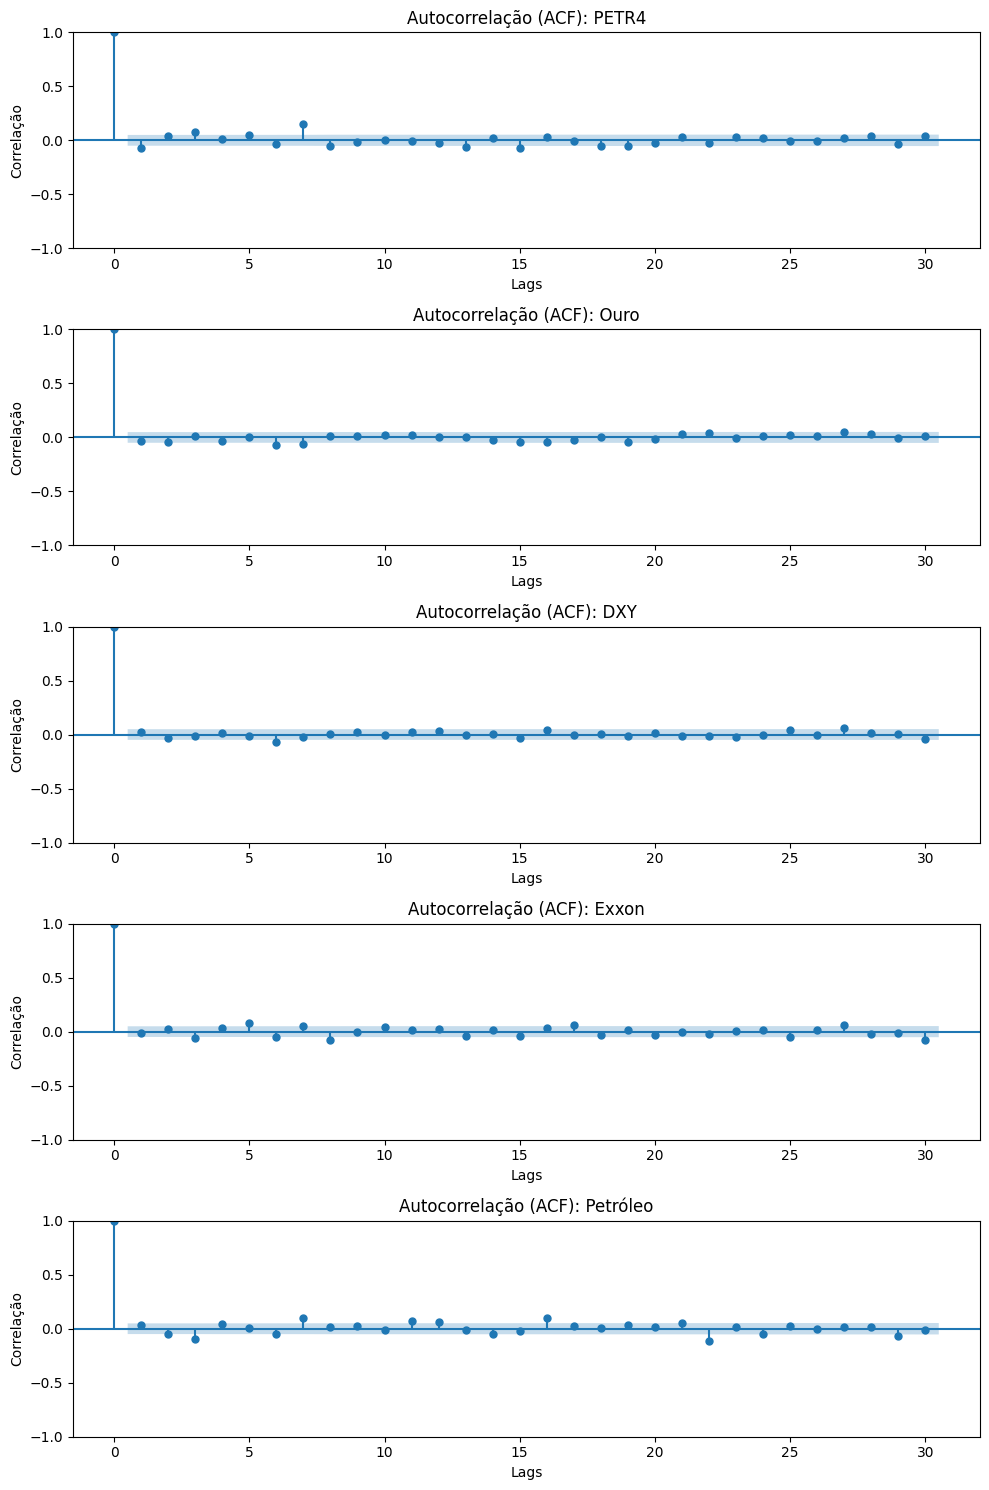

In [ ]:
# 2. Autocorrelação (ACF) dos Log-Retornos Diários Antes da Suavização (shift=1)
print("--- Autocorrelação (ACF) dos Log-Retornos Diários Brutos (Pré-Suavização, shift=1) ---")
run_autocorr_plots(df_raw, assets_list, colunas_log_raw, lags=30)


In [ ]:
# 3. Teste de Estacionariedade (ADF) nos Log-Retornos Diários Brutos
print("--- Teste ADF nos Log-Retornos Diários Brutos (Pré-Suavização) ---")
dict_raw_log = {f"raw_log_{asset}": df_raw[f"raw_log_ret_{asset}"] for asset in assets_list}
adf_raw_results = run_adf_tests(dict_raw_log)


--- Teste ADF nos Log-Retornos Diários Brutos (Pré-Suavização) ---


--- Análise de Resolução de Gabor ---


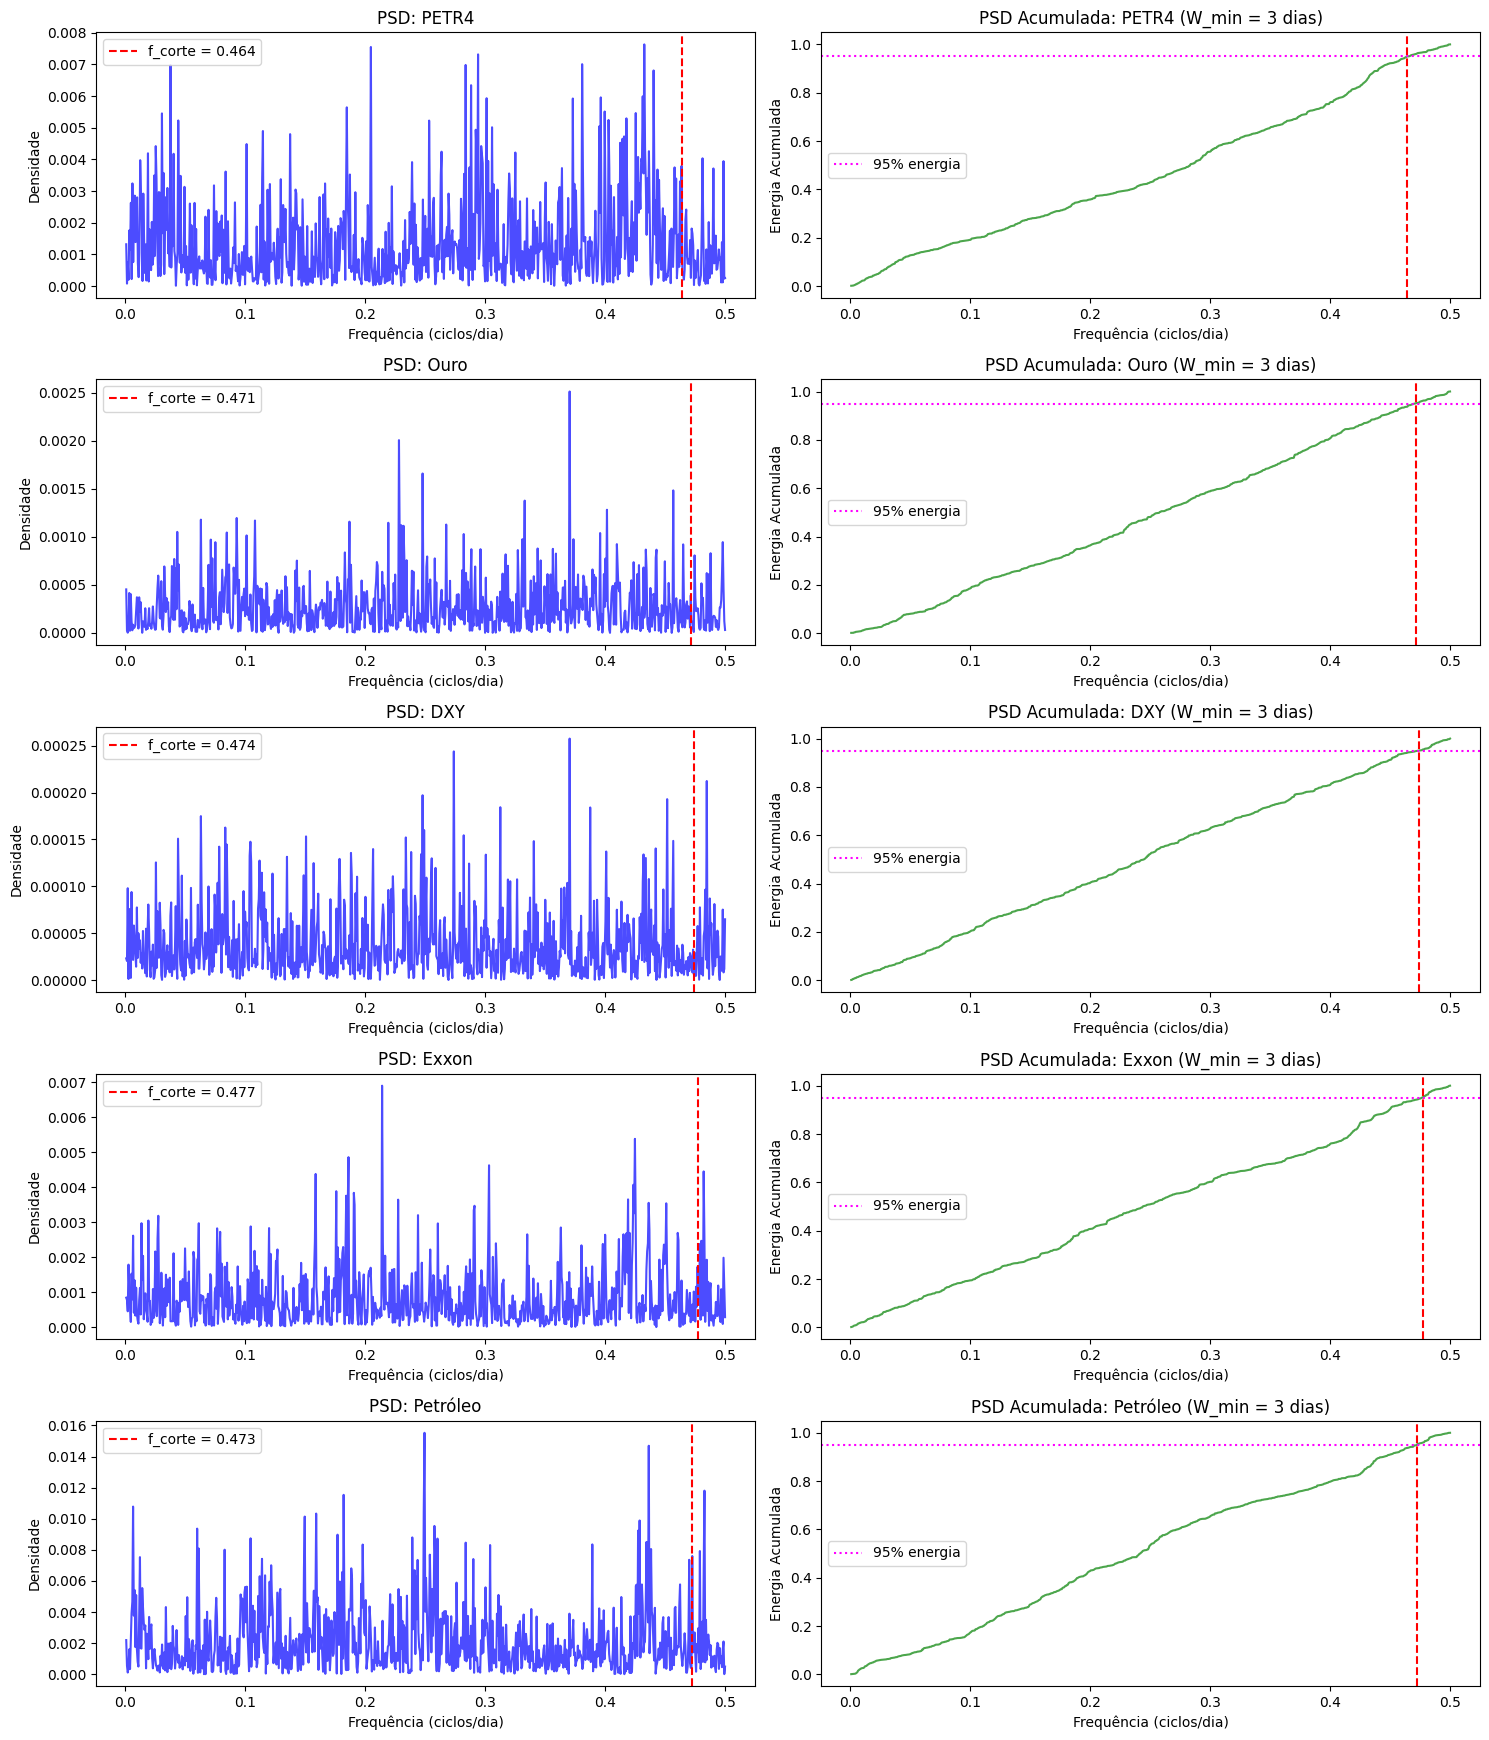


--- Resultados da Análise de Resolução de Gabor ---
          PETR4: f_corte = 0.4644 Hz | Janela mínima W = 3 dias
           Ouro: f_corte = 0.4714 Hz | Janela mínima W = 3 dias
            DXY: f_corte = 0.4740 Hz | Janela mínima W = 3 dias
          Exxon: f_corte = 0.4771 Hz | Janela mínima W = 3 dias
       Petróleo: f_corte = 0.4726 Hz | Janela mínima W = 3 dias
👉 Janela recomendada unificada (máximo dos ativos): 3 dias



In [ ]:
# 4. Análise de Resolução de Gabor (Princípio de Incerteza)
# Encontra a menor janela de suavização recomendada sem causar distorção temporal.
print("--- Análise de Resolução de Gabor ---")
global_w_min, w_min_dict = gabor_resolution_analysis(df_raw, assets_list, colunas_log_raw, energy_threshold=0.95)


In [ ]:
# 5. Aplicação de Suavização por Média Móvel nos Preços Close e Recálculo dos Log-Retornos
# Escolha do método de média móvel: 'sma', 'ema', 'triangular', 'gaussian', 'dema', 'tema'
METODO_MA = 'dema'  # Escolhemos EMA por ser robusta e ter menos lag do que SMA
df_final, colunas_log = apply_smoothing_and_log_returns(df_raw, assets_list, global_w_min, method=METODO_MA)

# Plotando o Phase Lag para o principal ativo (PETR4)
print(f"--- Phase Lag (Atraso de Fase) para PETR4 usando {METODO_MA.upper()} (Janela = {global_w_min} dias) ---")
plot_ma_phase_lag(df_raw, 'PETR4', global_w_min, method=METODO_MA)


--- Phase Lag (Atraso de Fase) para PETR4 usando DEMA (Janela = 3 dias) ---


In [ ]:
# 6. Comparação Visual de Métodos de Média Móvel (PETR4)
print("--- Comparação de Suavização por Diferentes Médias Móveis ---")
compare_moving_averages(df_raw, 'PETR4', global_w_min)


--- Comparação de Suavização por Diferentes Médias Móveis ---


--- Autocorrelação (ACF) dos Log-Retornos Diários Suavizados (DEMA, Janela=3 dias, shift=1) ---


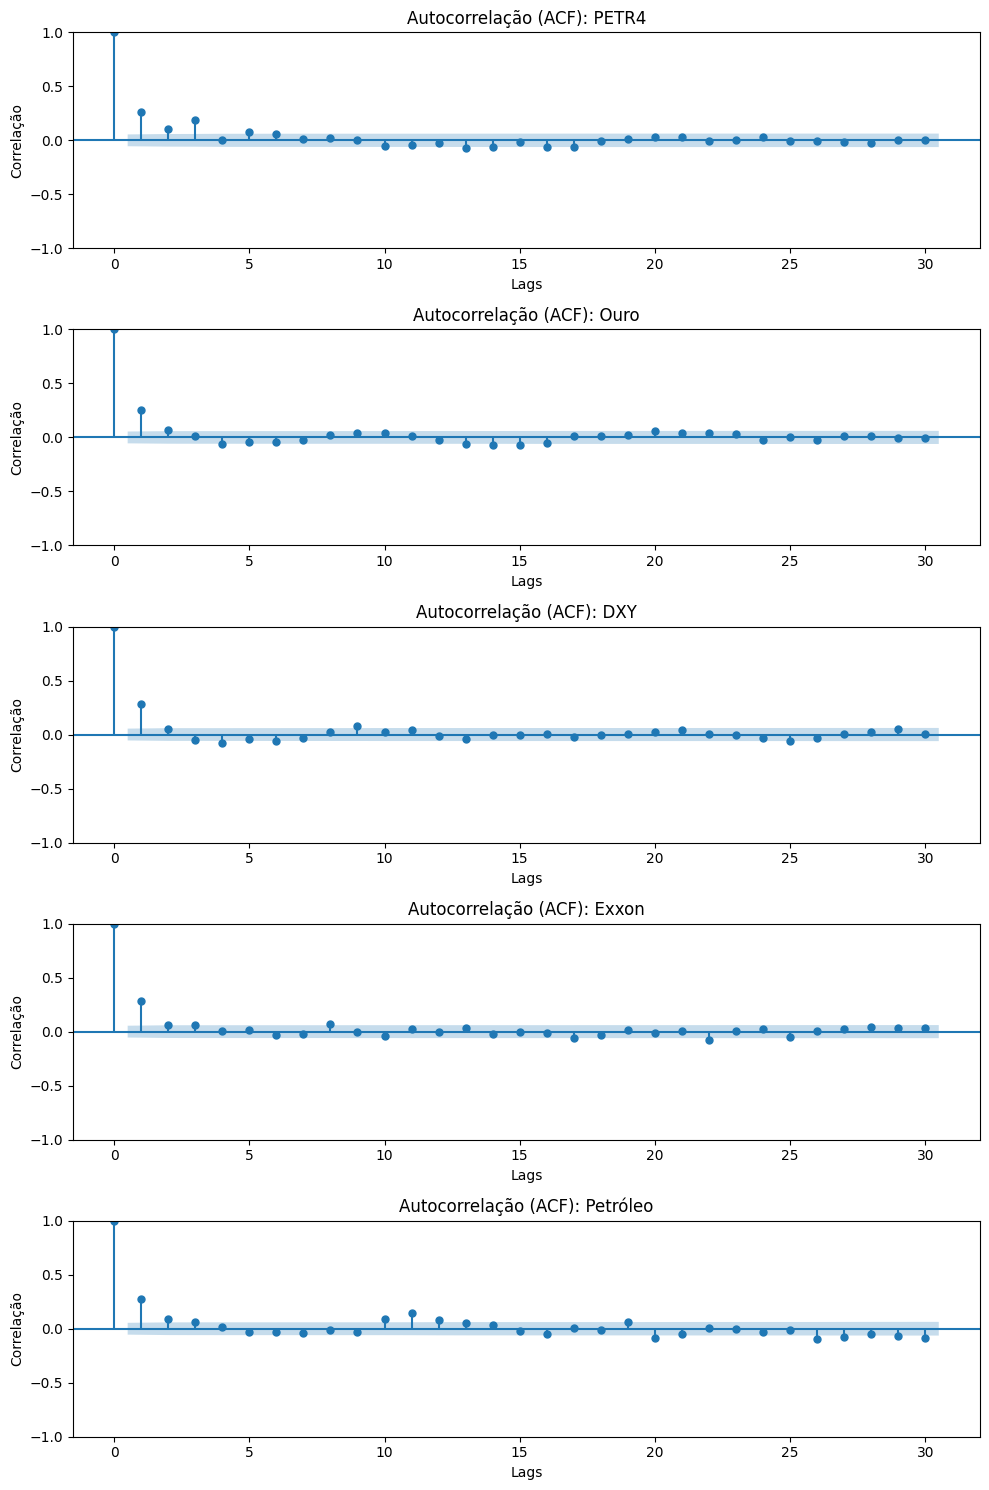

In [ ]:
# 7. Autocorrelação (ACF) dos Log-Retornos Diários Depois da Suavização (Pós-Suavização, shift=1)
print(f"--- Autocorrelação (ACF) dos Log-Retornos Diários Suavizados ({METODO_MA.upper()}, Janela={global_w_min} dias, shift=1) ---")
run_autocorr_plots(df_final, assets_list, colunas_log, lags=30)


--- Estatísticas Descritivas e Correlação das Séries Suavizadas ---


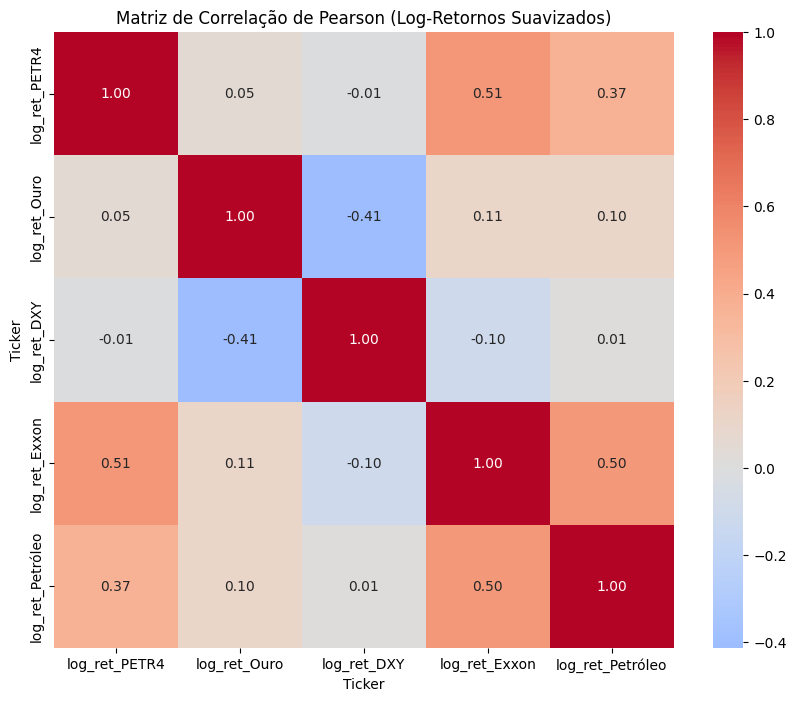

,Média,DP,Skewness,Kurtosis,Anderson-Stat,AD-Critico(5%)
PETR4,0.000586,0.020584,-3.487617,40.399575,27.419449,0.785
Ouro,0.000587,0.008942,-0.478412,3.461231,9.240154,0.785
DXY,0.000050,0.003472,-0.195426,2.389343,4.590975,0.785
Exxon,0.000546,0.016012,-0.552957,4.276476,6.770585,0.785
Petróleo,0.000969,0.028913,3.837727,81.608754,50.332938,0.785


In [ ]:
# 8. Estatísticas Descritivas e Matriz de Correlação da Série Suavizada
print("--- Estatísticas Descritivas e Correlação das Séries Suavizadas ---")
stats_df = run_full_stats(df_final, assets_list, colunas_log)
display(stats_df)


In [ ]:
# 9. Expoente de Hurst via Detrended Fluctuation Analysis (DFA)
print("--- Análise do Expoente de Hurst (DFA) nos Log-Retornos Suavizados ---")
hurst_results = run_hurst_analysis(df_final, assets_list, colunas_log, min_window=10)
display(hurst_results)


--- Análise do Expoente de Hurst (DFA) nos Log-Retornos Suavizados ---


,Ativo,Hurst (DFA),Interpretação
0,PETR4,0.551025,Persistente (Trend-following)
1,Ouro,0.476191,Random Walk (Eficiente)
2,DXY,0.524739,Random Walk (Eficiente)
3,Exxon,0.548236,Random Walk (Eficiente)
4,Petróleo,0.566883,Persistente (Trend-following)


In [ ]:
# 10. Teste ADF nos Log-Retornos Suavizados
print("--- Teste ADF nos Log-Retornos Suavizados ---")
dict_smoothed_log = {f"smoothed_log_{asset}": df_final[col] for asset, col in zip(assets_list, colunas_log)}
adf_smoothed_results = run_adf_tests(dict_smoothed_log)


--- Teste ADF nos Log-Retornos Suavizados ---


In [ ]:
# 11. Informação Mútua (Interativo com Plotly)
mi_results = run_mutual_info_matrix(df_final, assets_list, colunas_log)
plot_interactive_heatmap(mi_results, 'MI', 'Informação Mútua Interativa (Dependência Estatística - Lags Ótimos)',
                         x_name='Ativo_B', y_name='Ativo_A')


In [ ]:
# 12. Causalidade de Granger (Interativo com Plotly)
granger_results = run_granger_matrix(df_final, assets_list, colunas_log)
plot_interactive_heatmap(granger_results, 'p_value', 'Granger: P-Values (Perto de Azul/Roxo = Significativo < 0.05 - Lags Ótimos)', colorscale='RdBu', reverse_z=True, zmax=0.05)


In [ ]:
# 13. Teste de Cointegração Engle-Granger (Par a Par) nos Preços Fechamento
print("--- Teste de Cointegração Engle-Granger nos Preços de Fechamento ---")
coint_eg_results, eg_residuals = run_engle_granger_cointegration(df_raw, assets_list)
display(coint_eg_results.head(10))


--- Teste de Cointegração Engle-Granger nos Preços de Fechamento ---


,Ativo_A,Ativo_B,Beta,Alpha,coint_stat,p_value,coint_crit_5%,Cointegrado,Status
0,PETR4,Ouro,0.009938,-4.377941,-1.827228,0.616405,-3.340057,False,Executado
1,PETR4,DXY,0.938503,-74.783935,-0.093110,0.983487,-3.340057,False,Executado
2,PETR4,Exxon,0.308148,-6.709390,-2.070308,0.491893,-3.340062,False,Executado
3,PETR4,Petróleo,0.198975,4.993465,-0.285354,0.976544,-3.340057,False,Executado
4,Ouro,PETR4,64.332914,1133.186286,-1.257379,0.842229,-3.340057,False,Executado
5,Ouro,DXY,2.818345,2076.079621,1.189474,1.000000,-3.339923,False,Executado
6,Ouro,Exxon,19.522197,726.717569,-0.673123,0.949461,-3.339925,False,Executado
7,Ouro,Petróleo,3.161544,2134.794384,1.025950,1.000000,-3.339921,False,Executado
8,DXY,PETR4,0.214358,95.926992,-1.755441,0.651102,-3.340057,False,Executado
9,DXY,Ouro,0.000101,99.786108,-1.574290,0.731619,-3.339923,False,Executado


In [ ]:
# --- Demonstração do Pré-Teste ADF Condicional ---
# O teste de cointegração não deve rodar sobre séries estacionárias.
# Aqui tentamos rodar o teste Engle-Granger sobre os retornos simples diários brutos (que são estacionários).
# A lógica condicional deve identificar as séries como estacionárias e pular a cointegração automaticamente.
print("--- Teste de Cointegração Engle-Granger nos Retornos Simples Diários (Demonstração da Lógica Condicional) ---")
colunas_sim_ret_raw = [f'raw_sim_ret_{asset}' for asset in assets_list]
coint_sim_results, _ = run_engle_granger_cointegration(df_raw, colunas_sim_ret_raw)
display(coint_sim_results)


--- Teste de Cointegração Engle-Granger nos Retornos Simples Diários (Demonstração da Lógica Condicional) ---


,Ativo_A,Ativo_B,Beta,Alpha,coint_stat,p_value,coint_crit_5%,Cointegrado,Status
0,raw_sim_ret_PETR4,raw_sim_ret_Ouro,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_PETR4 e raw...
1,raw_sim_ret_PETR4,raw_sim_ret_DXY,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_PETR4 e raw...
2,raw_sim_ret_PETR4,raw_sim_ret_Exxon,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_PETR4 e raw...
3,raw_sim_ret_PETR4,raw_sim_ret_Petróleo,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_PETR4 e raw...
4,raw_sim_ret_Ouro,raw_sim_ret_PETR4,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_Ouro e raw_...
5,raw_sim_ret_Ouro,raw_sim_ret_DXY,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_Ouro e raw_...
6,raw_sim_ret_Ouro,raw_sim_ret_Exxon,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_Ouro e raw_...
7,raw_sim_ret_Ouro,raw_sim_ret_Petróleo,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_Ouro e raw_...
8,raw_sim_ret_DXY,raw_sim_ret_PETR4,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_DXY e raw_s...
9,raw_sim_ret_DXY,raw_sim_ret_Ouro,NaN,NaN,NaN,NaN,NaN,False,Pulado (Estacionário: raw_sim_ret_DXY e raw_s...


In [ ]:
# 14. Teste de Cointegração de Johansen (Multivariado) nos Preços Fechamento
print("--- Teste de Cointegração de Johansen (Preços Close) ---")
johansen_results = run_johansen_cointegration(df_raw, assets_list)


--- Teste de Cointegração de Johansen (Preços Close) ---


In [ ]:
# 15. Teste ADF nos Resíduos da Cointegração Engle-Granger
print("--- Teste ADF nos Resíduos de Cointegração (Spreads) ---")
adf_coint_residuals = run_adf_tests(eg_residuals)


--- Teste ADF nos Resíduos de Cointegração (Spreads) ---


In [ ]:
# 16. Entropia de Shannon
print("--- Entropia de Shannon por Ativo ---")
entropy_results = run_entropy_analysis(df_final, assets_list, colunas_log)
display(entropy_results)


In [ ]:
# 17. Divergência de Jensen-Shannon
print("--- Divergência de Jensen-Shannon ---")
jsd_results = run_jsd_matrix(df_final, assets_list, colunas_log)


In [ ]:
# 18. Transferência de Entropia (Bivariate) com Lags Ótimos da MI
lag_map = get_optimal_mi_lags(mi_results, assets_list)
print("--- Transferência de Entropia Bivariate com Lags Ótimos da MI ---")
te_results = run_transfer_entropy_matrix(df_final, assets_list, colunas_log, lag_map, n_bins=10)


In [ ]:
# 19. Decomposição Sazonal de Preços (Close)
# Período = 21 dias (aproximadamente 1 mês de negociação)
print("--- Decomposição Sazonal de Preços (Modelo Aditivo, Período=21) ---")
decomp_prices_resid = run_seasonal_decomposition(df_raw, assets_list, assets_list, period=21, model='additive')


In [ ]:
# 20. Decomposição Sazonal de Log-Retornos
print("--- Decomposição Sazonal de Log-Retornos (Modelo Aditivo, Período=21) ---")
decomp_log_resid = run_seasonal_decomposition(df_final, assets_list, colunas_log, period=21, model='additive')


In [ ]:
# 21. Teste ADF nos Resíduos da Decomposição Sazonal (Preços e Log-Retornos)
print("--- Teste ADF nos Resíduos da Decomposição Sazonal ---")
decomp_all_resid = {}
for k, v in decomp_prices_resid.items():
    decomp_all_resid[f"Preços_{k}"] = v
for k, v in decomp_log_resid.items():
    decomp_all_resid[f"LogRet_{k}"] = v
adf_decomp_results = run_adf_tests(decomp_all_resid)


In [ ]:
# 22. Teste de Quebra Estrutural (Bai-Perron / PELT) nos Preços
print("--- Detecção de Quebras Estruturais nas Séries de Preços ---")
breaks_results = run_structural_breaks(df_raw, assets_list, model='l2', min_size=21, penalty_factor=3.0)
display(breaks_results)


--- Detecção de Quebras Estruturais nas Séries de Preços ---


,Ativo,N_Quebras,Datas_Quebras
0,PETR4,4,"2022-01-17, 2023-06-13, 2023-12-26, 2026-02-18"
1,Ouro,3,"2024-03-27, 2025-03-12, 2025-10-07"
2,DXY,7,"2020-07-23, 2021-11-11, 2022-04-21, 2022-08-23..."
3,Exxon,5,"2021-02-19, 2022-01-25, 2022-10-05, 2024-03-13..."
4,Petróleo,8,"2020-03-09, 2020-05-19, 2021-01-06, 2021-06-01..."


In [ ]:
# 23. Transferência de Entropia Condicional + Resumo Consolidado com Lags Ótimos da MI
ATIVO_ALVO = 'PETR4'

print(f"--- TE Condicional para {ATIVO_ALVO} ---")
cte_results = run_conditional_transfer_entropy(df_final, assets_list, colunas_log, target=ATIVO_ALVO, lag_map=lag_map, n_bins=10)

# Resumo Consolidado Expandido
summary = summarize_target_distribution(
    ATIVO_ALVO,
    entropy_results,
    jsd_results,
    mi_results,
    te_results,
    cte_results,
    granger_results,
    lag_map=lag_map,
    hurst_df=hurst_results,
    coint_df=coint_eg_results,
    breaks_df=breaks_results
)


--- TE Condicional para PETR4 ---



  RESUMO CONSOLIDADO ROBUSTO — Distribuição Alvo: PETR4

📊 Entropia de Shannon: 3.9176 bits
   → Mede a imprevisibilidade. Maior entropia = mais ruído estatístico.

📈 Expoente de Hurst (DFA): H = 0.8970 (Persistente (Trend-following))
   → Comportamento persistente significante (forte seguidor de tendência).

⚠️ Quebras Estruturais (Mudança de Regime):
   Total de Quebras Detectadas: 4
   Datas dos Eventos de Quebra: 2022-01-17, 2023-06-13, 2023-12-26, 2026-02-18

⛓️ Cointegração Estocástica (como Dependente A = const + Beta*B + e):
   vs         Ouro: p-value = 0.6164 | ❌ Não Cointegrado (Beta = 0.0099)
   vs          DXY: p-value = 0.9835 | ❌ Não Cointegrado (Beta = 0.9385)
   vs        Exxon: p-value = 0.4919 | ❌ Não Cointegrado (Beta = 0.3081)
   vs     Petróleo: p-value = 0.9765 | ❌ Não Cointegrado (Beta = 0.1990)
   → Nenhuma cointegração bivariada forte com o alvo detectada no longo prazo.

📐 Divergência de Jensen-Shannon (similaridade de distribuições):
          Exxon: JSD = 

,JSD,MI_max,Lag Ótimo,TE,Coint_p (EG),Cointegrado?,Granger_p
Ativo,,,,,,,
Exxon,0.023583,0.150660,2,0.059616,0.491893,Não,0.000145
Petróleo,0.028219,0.118291,2,0.071357,0.976544,Não,0.000092
Ouro,0.134081,0.074562,15,0.073526,0.616405,Não,0.001024
DXY,0.400166,0.066021,29,0.086744,0.983487,Não,0.016118


## Extensão: Análise Multi-Escala Temporal (Séries Suavizadas)

Esta seção implementa a análise multi-escala temporal baseada na extensão, adaptada para utilizar as **séries de preços suavizadas** (conforme a média móvel configurada no notebook original) e avaliar tanto o **log-retorno** após suavização quanto o **retorno simples** após suavização para as janelas diária ($k=1$), semanal ($k=5$) e mensal ($k=21$).

**Pipeline:**
1. Cálculo de retornos (log e simples) em 3 escalas ($k=1, 5, 21$) a partir dos preços suavizados.
2. Teste ADF em todas as combinações para verificar a estacionariedade.
3. Teste de Hurst (DFA) em todas as combinações para medir a razão sinal-ruído.
4. Seleção automática da combinação (escala + tipo de retorno) que seja estacionária e maximize a distância de um passeio aleatório ($|H - 0.5|$ máximo).
5. Execução do pipeline causal completo (MI, Granger, TE, TE Condicional e Resumo) na melhor combinação.

In [ ]:
# --- A. Cálculo de Retornos Multi-Escala Suavizados ---
print("── Calculando retornos multi-escala suavizados (Log e Simples) ──")
print(f"   Método de Média Móvel: {METODO_MA.upper()} | Janela de Suavização: {global_w_min} dias\n")

multiscale_smoothed_data = compute_multiscale_smoothed_returns(df_raw, assets_list, global_w_min, method=METODO_MA)

# Exibindo as primeiras linhas da escala mensal (k=21) em log e simples
print("Primeiras linhas dos retornos logarítmicos mensais suavizados (k=21):")
display(multiscale_smoothed_data['log_mensal']['df'][multiscale_smoothed_data['log_mensal']['cols']].head())
print("\nPrimeiras linhas dos retornos simples mensais suavizados (k=21):")
display(multiscale_smoothed_data['sim_mensal']['df'][multiscale_smoothed_data['sim_mensal']['cols']].head())


── Calculando retornos multi-escala suavizados (Log e Simples) ──
   Método de Média Móvel: DEMA | Janela de Suavização: 30 dias

Primeiras linhas dos retornos logarítmicos mensais suavizados (k=21):


Ticker,log_ret_21d_PETR4,log_ret_21d_Ouro,log_ret_21d_DXY,log_ret_21d_Exxon,log_ret_21d_Petróleo
Date,,,,,
2020-01-31,-0.053062,0.029359,0.008650,-0.073985,-0.108583
2020-02-03,-0.057339,0.028520,0.008992,-0.084590,-0.126152
2020-02-04,-0.060705,0.024228,0.009719,-0.096661,-0.143711
2020-02-05,-0.064263,0.020471,0.010365,-0.101203,-0.155781
2020-02-06,-0.063237,0.018815,0.010822,-0.105051,-0.159922



Primeiras linhas dos retornos simples mensais suavizados (k=21):


Ticker,sim_ret_21d_PETR4,sim_ret_21d_Ouro,sim_ret_21d_DXY,sim_ret_21d_Exxon,sim_ret_21d_Petróleo
Date,,,,,
2020-01-31,-0.051679,0.029794,0.008688,-0.071315,-0.102895
2020-02-03,-0.055726,0.028931,0.009033,-0.081111,-0.118519
2020-02-04,-0.058899,0.024524,0.009766,-0.092136,-0.133862
2020-02-05,-0.062242,0.020681,0.010419,-0.096251,-0.144254
2020-02-06,-0.061279,0.018993,0.010881,-0.099721,-0.147790


In [ ]:
# --- B. Teste ADF em todas as combinações ---
print("\n" + "="*60)
print("  TESTE ADF — TODAS AS ESCALAS E RAZÕES SUAVIZADAS")
print("="*60)

adf_by_scale = {}
for scale_key, data in multiscale_smoothed_data.items():
    print(f"\n▶ Combinação: {data['label']}")
    series_dict = {
        f"{asset} [{scale_key}]": data['df'][col]
        for asset, col in zip(assets_list, data['cols'])
    }
    adf_result = run_adf_tests(series_dict)
    adf_by_scale[scale_key] = adf_result

    n_estac = (adf_result['Estacionária'] == 'Sim').sum()
    print(f"   → {n_estac}/{len(assets_list)} séries estacionárias a 5%")



  TESTE ADF — TODAS AS ESCALAS E RAZÕES SUAVIZADAS

▶ Combinação: Log-Retorno diario (k=1)


   → 5/5 séries estacionárias a 5%

▶ Combinação: Retorno Simples diario (k=1)


   → 5/5 séries estacionárias a 5%

▶ Combinação: Log-Retorno semanal (k=5)


   → 5/5 séries estacionárias a 5%

▶ Combinação: Retorno Simples semanal (k=5)


   → 5/5 séries estacionárias a 5%

▶ Combinação: Log-Retorno mensal (k=21)


   → 5/5 séries estacionárias a 5%

▶ Combinação: Retorno Simples mensal (k=21)


   → 5/5 séries estacionárias a 5%


In [ ]:
# --- C. Teste de Hurst (DFA) em todas as combinações ---
print("\n" + "="*60)
print("  EXPOENTE DE HURST (DFA) — TODAS AS ESCALAS E RAZÕES SUAVIZADAS")
print("  Quanto mais distante de 0.5, maior o sinal preditivo (sinal-ruído)")
print("="*60)

hurst_by_scale = {}
hurst_summary_rows = []

for scale_key, data in multiscale_smoothed_data.items():
    print(f"\n▶ Combinação: {data['label']}")
    h_df = run_hurst_analysis(
        data['df'], assets_list, data['cols'], min_window=10
    )
    hurst_by_scale[scale_key] = h_df

    # Calcular distância média de 0.5
    h_df['dist_0.5'] = np.abs(h_df['Hurst (DFA)'] - 0.5)
    mean_dist = h_df['dist_0.5'].mean()
    mean_h    = h_df['Hurst (DFA)'].mean()

    # Obter o número de séries estacionárias para a tabela comparativa
    n_estac = (adf_by_scale[scale_key]['Estacionária'] == 'Sim').sum()

    hurst_summary_rows.append({
        'Combinação': scale_key,
        'Label': data['label'],
        'Tipo': data['type'],
        'k (dias)': data['k'],
        'H médio': mean_h,
        '|H - 0.5| médio': mean_dist,
        'N Estacionárias (ADF)': f"{n_estac}/{len(assets_list)}",
        'Estacionária': n_estac >= len(assets_list) / 2, # Pelo menos metade estacionária
        'N observações': len(data['df'])
    })

    print(f"   Hurst médio: {mean_h:.4f}  |  |H - 0.5| médio: {mean_dist:.4f}")

hurst_comparison = pd.DataFrame(hurst_summary_rows).set_index('Combinação')



  EXPOENTE DE HURST (DFA) — TODAS AS ESCALAS E RAZÕES SUAVIZADAS
  Quanto mais distante de 0.5, maior o sinal preditivo (sinal-ruído)

▶ Combinação: Log-Retorno diario (k=1)


   Hurst médio: 0.8951  |  |H - 0.5| médio: 0.3951

▶ Combinação: Retorno Simples diario (k=1)


   Hurst médio: 0.8949  |  |H - 0.5| médio: 0.3949

▶ Combinação: Log-Retorno semanal (k=5)


   Hurst médio: 0.9130  |  |H - 0.5| médio: 0.4130

▶ Combinação: Retorno Simples semanal (k=5)


   Hurst médio: 0.9165  |  |H - 0.5| médio: 0.4165

▶ Combinação: Log-Retorno mensal (k=21)


   Hurst médio: 1.1497  |  |H - 0.5| médio: 0.6497

▶ Combinação: Retorno Simples mensal (k=21)


   Hurst médio: 1.1356  |  |H - 0.5| médio: 0.6356


In [ ]:
# --- D. Seleção Automática da Melhor Escala e Razão ---
print("\n" + "="*60)
print("  TABELA COMPARATIVA — SELEÇÃO DE SÉRIE E RAZÃO DE RETORNO")
print("="*60)
display(hurst_comparison)

# Filtrar apenas as escalas/razões onde pelo menos metade das séries são estacionárias (pré-requisito econométrico)
valid_candidates = hurst_comparison[hurst_comparison['Estacionária'] == True]

if len(valid_candidates) == 0:
    print("⚠️ Nenhuma combinação atendeu ao pré-requisito de ter a maioria das séries estacionárias.")
    print("Usando todas as combinações disponíveis para a seleção.")
    valid_candidates = hurst_comparison

# Selecionar a combinação com maior distância de Hurst de 0.5
best_comb = valid_candidates['|H - 0.5| médio'].idxmax()
best_k = int(hurst_comparison.loc[best_comb, 'k (dias)'])
best_type = hurst_comparison.loc[best_comb, 'Tipo']
best_label = hurst_comparison.loc[best_comb, 'Label']
best_h_dist = hurst_comparison.loc[best_comb, '|H - 0.5| médio']

print(f"\n✅ Combinação selecionada automaticamente: [{best_comb.upper()}]")
print(f"   Descrição: {best_label}")
print(f"   Razão sinal-ruído (|H-0.5| médio): {best_h_dist:.4f}")
print(f"   Pipeline causal downstream será executado nesta série.\n")

# Atalho para os dados selecionados
best_scale_data = multiscale_smoothed_data[best_comb]
df_best_scale = best_scale_data['df']
cols_best_scale = best_scale_data['cols']

# Plotly para comparar os Hurst de cada combinação
fig_comp = go.Figure()
colors_comp = {
    'log_diario': '#636efa', 'log_semanal': '#ef553b', 'log_mensal': '#00cc96',
    'sim_diario': '#ab63fa', 'sim_semanal': '#ffa15a', 'sim_mensal': '#19d3f3'
}

for scale_key, h_df in hurst_by_scale.items():
    fig_comp.add_trace(go.Bar(
        x=h_df['Ativo'],
        y=h_df['Hurst (DFA)'],
        name=scale_key,
        marker_color=colors_comp.get(scale_key),
        opacity=0.85
    ))

fig_comp.add_hline(
    y=0.5, line_dash="dash", line_color="white",
    annotation_text="Passeio Aleatório (H=0.5)",
    annotation_position="top right"
)
fig_comp.update_layout(
    title='Expoente de Hurst (DFA) por Ativo, Escala e Razão de Retorno',
    xaxis_title='Ativo',
    yaxis_title='Hurst (DFA)',
    barmode='group',
    template='plotly_white',
    height=500
)
fig_comp.show()



  TABELA COMPARATIVA — SELEÇÃO DE SÉRIE E RAZÃO DE RETORNO


,Label,Tipo,k (dias),H médio,|H - 0.5| médio,N Estacionárias (ADF),Estacionária,N observações
Combinação,,,,,,,,
log_diario,Log-Retorno diario (k=1),log,1,0.895119,0.395119,5/5,True,1278
sim_diario,Retorno Simples diario (k=1),sim,1,0.894875,0.394875,5/5,True,1278
log_semanal,Log-Retorno semanal (k=5),log,5,0.912961,0.412961,5/5,True,1278
sim_semanal,Retorno Simples semanal (k=5),sim,5,0.916512,0.416512,5/5,True,1278
log_mensal,Log-Retorno mensal (k=21),log,21,1.149719,0.649719,5/5,True,1278
sim_mensal,Retorno Simples mensal (k=21),sim,21,1.135612,0.635612,5/5,True,1278



✅ Combinação selecionada automaticamente: [LOG_MENSAL]
   Descrição: Log-Retorno mensal (k=21)
   Razão sinal-ruído (|H-0.5| médio): 0.6497
   Pipeline causal downstream será executado nesta série.



In [ ]:
# --- E. Execução do Pipeline Causal na Escala e Razão Selecionadas ---
print(f"\n{'='*75}")
print(f"  PIPELINE CAUSAL ROBUSTO — SÉRIE SELECIONADA: [{best_comb.upper()}]")
print(f"  ({best_label})")
print(f"{'='*75}\n")

# Verificar se as séries são estacionárias
adf_best_scale = adf_by_scale[best_comb]
n_estac = (adf_best_scale['Estacionária'] == 'Sim').sum()
if n_estac < len(assets_list):
    print(f"⚠️ Atenção: apenas {n_estac}/{len(assets_list)} séries são estacionárias na série selecionada.")
    print("Isso pode afetar a validade estatística do teste de causalidade de Granger de curto prazo.\n")
else:
    print(f"✅ {n_estac}/{len(assets_list)} séries estacionárias — pré-requisito satisfeito.\n")

# 1. Informação Mútua
print(f"── 1. Informação Mútua [{best_comb}] ──")
mi_best_scale = run_mutual_info_matrix(df_best_scale, assets_list, cols_best_scale)
plot_interactive_heatmap(
    mi_best_scale, 'MI',
    f'Informação Mútua [{best_label}] — Dependência Estatística (Lags Ótimos)',
    x_name='Ativo_B', y_name='Ativo_A'
)

# 2. Causalidade de Granger (Linear)
print(f"\n── 2. Causalidade de Granger [{best_comb}] ──")
granger_best_scale = run_granger_matrix(df_best_scale, assets_list, cols_best_scale)
plot_interactive_heatmap(
    granger_best_scale, 'p_value',
    f'Granger P-Values [{best_label}] — Azul/Roxo = Significativo (<0.05)',
    colorscale='RdBu', reverse_z=True, zmax=0.05
)

# 3. Entropia de Shannon e JSD
print(f"\n── 3. Entropia de Shannon e JSD [{best_comb}] ──")
entropy_best_scale = run_entropy_analysis(df_best_scale, assets_list, cols_best_scale)
jsd_best_scale     = run_jsd_matrix(df_best_scale, assets_list, cols_best_scale)

# 4. Transferência de Entropia Bivariada
print(f"\n── 4. Transferência de Entropia [{best_comb}] ──")
lag_map_best_scale = get_optimal_mi_lags(mi_best_scale, assets_list)
te_best_scale      = run_transfer_entropy_matrix(
    df_best_scale, assets_list, cols_best_scale, lag_map_best_scale, n_bins=50
)

# 5. Transferência de Entropia Condicional + Resumo Consolidado
print(f"\n── 5. TE Condicional e Resumo [{best_comb}] ──")
cte_best_scale = run_conditional_transfer_entropy(
    df_best_scale, assets_list, cols_best_scale,
    target=ATIVO_ALVO, lag_map=lag_map_best_scale, n_bins=50
)

# Resumo Consolidado na escala selecionada
summary_best_scale = summarize_target_distribution(
    ATIVO_ALVO,
    entropy_best_scale,
    jsd_best_scale,
    mi_best_scale,
    te_best_scale,
    cte_best_scale,
    granger_best_scale,
    lag_map=lag_map_best_scale,
    hurst_df=hurst_by_scale[best_comb],
    coint_df=coint_eg_results,   # Cointegração usa preços — não depende da escala de retornos
    breaks_df=breaks_results     # Quebras estruturais também usam preços Close
)



  PIPELINE CAUSAL ROBUSTO — SÉRIE SELECIONADA: [LOG_MENSAL]
  (Log-Retorno mensal (k=21))

✅ 5/5 séries estacionárias — pré-requisito satisfeito.

── 1. Informação Mútua [log_mensal] ──



── 2. Causalidade de Granger [log_mensal] ──



── 3. Entropia de Shannon e JSD [log_mensal] ──



── 4. Transferência de Entropia [log_mensal] ──



── 5. TE Condicional e Resumo [log_mensal] ──



  RESUMO CONSOLIDADO ROBUSTO — Distribuição Alvo: PETR4

📊 Entropia de Shannon: 4.2017 bits
   → Mede a imprevisibilidade. Maior entropia = mais ruído estatístico.

📈 Expoente de Hurst (DFA): H = 1.1267 (Persistente (Trend-following))
   → Comportamento persistente significante (forte seguidor de tendência).

⚠️ Quebras Estruturais (Mudança de Regime):
   Total de Quebras Detectadas: 4
   Datas dos Eventos de Quebra: 2022-01-17, 2023-06-13, 2023-12-26, 2026-02-18

⛓️ Cointegração Estocástica (como Dependente A = const + Beta*B + e):
   vs         Ouro: p-value = 0.6164 | ❌ Não Cointegrado (Beta = 0.0099)
   vs          DXY: p-value = 0.9835 | ❌ Não Cointegrado (Beta = 0.9385)
   vs        Exxon: p-value = 0.4919 | ❌ Não Cointegrado (Beta = 0.3081)
   vs     Petróleo: p-value = 0.9765 | ❌ Não Cointegrado (Beta = 0.1990)
   → Nenhuma cointegração bivariada forte com o alvo detectada no longo prazo.

📐 Divergência de Jensen-Shannon (similaridade de distribuições):
          Exxon: JSD = 

,JSD,MI_max,Lag Ótimo,TE,Coint_p (EG),Cointegrado?,Granger_p
Ativo,,,,,,,
Exxon,0.041286,0.614621,2,0.031735,0.491893,Não,4.584398e-02
Petróleo,0.048255,0.499724,1,0.022589,0.976544,Não,1.788056e-11
Ouro,0.159154,0.396387,21,0.043328,0.616405,Não,1.232752e-02
DXY,0.415282,0.391341,6,0.050320,0.983487,Não,1.920383e-04
